# Part-5 — SSL Resume: fine-tune from epoch 10 + full analysis

In [1]:
import os, gc, time, json, warnings, math, sys
from pathlib import Path
from copy import deepcopy
from dataclasses import dataclass
from typing import Literal, Optional, Tuple

import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import resample_poly
from math import gcd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from einops import rearrange
from timm.layers.drop import DropPath
from timm.layers.mlp import Mlp
from timm.layers.weight_init import trunc_normal_ as __call_trunc_normal_

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve, silhouette_score,
)

try:
    from thop import profile as thop_profile
    HAS_THOP = True
except ImportError:
    HAS_THOP = False

try:
    import umap as umap_module
    HAS_UMAP = True
except ImportError:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               'umap-learn', '-q'])
        import umap as umap_module
        HAS_UMAP = True
    except Exception:
        HAS_UMAP = False
        print("UMAP not available — will skip UMAP plots")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')


2026-03-25 09:00:10.076184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774429210.275148      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774429210.336714      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774429210.824745      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774429210.824799      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774429210.824804      24 computation_placer.cc:177] computation placer alr

# Configuration

In [2]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')
    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir())
    def _search(root, depth=0):
        if depth > 5: return None
        if _has_subjects(root): return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    r = _search(child, depth + 1)
                    if r is not None: return r
        except PermissionError: pass
        return None
    r = _search(base)
    return r if r else Path('/kaggle/input/ninapro-db7/Dataset')


def _find_cache_dir() -> Path:
    # Locate cache_exB from Part-1
    base  = Path('/kaggle/input')
    probe = 'cache_exB/subj_01_exB.npz'
    def _search(root, depth=0):
        if depth > 5: return None
        try:
            if (root / probe).exists(): return root
            for child in sorted(root.iterdir()):
                if child.is_dir() and not child.name.startswith('.'):
                    r = _search(child, depth + 1)
                    if r is not None: return r
        except PermissionError: pass
        return None
    found = _search(base)
    if found:
        print(f"  [cache-detect]  cache_exB found in {found}")
        return found / 'cache_exB'
    fallback = base / 'notebooks/atkiyamaisha90/part-1/cache_exB'
    print(f"  [cache-detect]  not found; falling back to {fallback}")
    return fallback


def _find_part4_ckpt_dir() -> Path:
    # Find Part-4 ckpts_exB containing the SSL pretrained model.
    # Identifies Part-4 output by presence of the SSL pretraining file.
    base   = Path('/kaggle/input/notebooks/atkiyamaisha90')
    target = 'tinymyo_90_10_ssl_ssl_pretrain.pt'
    found  = []
    def _search(root, depth=0):
        if depth > 5: return
        try:
            candidate = root / 'ckpts_exB' / target
            if candidate.exists():
                found.append((candidate.stat().st_mtime, root / 'ckpts_exB'))
            for child in sorted(root.iterdir()):
                if child.is_dir() and not child.name.startswith('.'):
                    _search(child, depth + 1)
        except PermissionError: pass
    _search(base)
    if found:
        found.sort(key=lambda x: x[0], reverse=True)
        chosen = found[0][1]
        print(f"  [part4-ckpt]    found in {chosen}")
        return chosen
    fallback = base / 'notebooks/atkiyamaisha90/part-4-ssl/ckpts_exB'
    print(f"  [part4-ckpt]    not found; falling back to {fallback}")
    return fallback


def _find_memmap_dir() -> Path:
    # Look for the 6.73 GB memmap written by Part-4 in previous output.
    base  = Path('/kaggle/input')
    probe = 'memmap_windows/meta.json'
    def _search(root, depth=0):
        if depth > 5: return None
        try:
            if (root / probe).exists(): return root / 'memmap_windows'
            for child in sorted(root.iterdir()):
                if child.is_dir() and not child.name.startswith('.'):
                    r = _search(child, depth + 1)
                    if r is not None: return r
        except PermissionError: pass
        return None
    found = _search(base)
    if found:
        print(f"  [memmap-detect] existing memmap found in {found}")
        return found
    # Fall back to writing a new one in working dir
    print("  [memmap-detect] no existing memmap; will build in /kaggle/working")
    return Path('/kaggle/working/memmap_windows')


In [3]:
class Config:
    # Read-only inputs
    DATA_CACHE_DIR  = _find_cache_dir()       # Part-1: 22 subject .npz caches
    PART4_CKPT_DIR  = _find_part4_ckpt_dir()  # Part-4: SSL model + finetune ckpt
    PREV_MEMMAP_DIR = _find_memmap_dir()      # Part-4: pre-built 6.73 GB memmap

    # Writable outputs for this run
    KAGGLE_WORKING = Path('/kaggle/working')
    CKPT_DIR       = KAGGLE_WORKING / 'ckpts_exB'
    PLOT_DIR       = KAGGLE_WORKING / 'plots_exB'
    RESULTS_DIR    = KAGGLE_WORKING / 'results_exB'

    KAGGLE_INPUT   = _find_kaggle_input()

    SUBJECTS       = list(range(1, 23))
    EMG_FS         = 2000
    ACC_FS         = 148
    TARGET_FS      = 2000
    EMG_KEY        = 'emg'
    ACC_KEY        = 'acc'
    LBL_KEY        = 'restimulus'
    GESTURE_MIN    = 13
    GESTURE_MAX    = 29

    WIN_MS         = 200
    STEP_MS        = 100
    WIN_SAMPLES    = int(WIN_MS  * TARGET_FS / 1000)
    STEP_SAMPLES   = int(STEP_MS * TARGET_FS / 1000)

    SPLIT_RATIOS      = [(0.90, 0.10)]
    VAL_FRAC_OF_TRAIN = 0.10

    # Fine-tune budget (tighter than default to fit in 43200s)
    MIN_EPOCHS         = 10
    MAX_EPOCHS         = 100
    PATIENCE           = 10
    FINETUNE_MAX_WALL  = 28000  # stop fine-tuning after this many wall-seconds
    CHECKPOINT_EVERY_N = 5
    BATCH_SIZE         = 256
    LR                 = 1e-3
    WEIGHT_DECAY       = 1e-4
    NUM_WORKERS        = 0      # 0 = no multiprocessing, avoids fork errors in Kaggle

    # TinyMyo architecture (must match Parts 1-4 exactly)
    TM_PATCH_SIZE  = 20
    TM_EMBED_DIM   = 128
    TM_N_LAYER     = 4
    TM_N_HEAD      = 4
    TM_MLP_RATIO   = 4
    TM_QKV_BIAS    = True
    TM_ATTN_DROP   = 0.1
    TM_PROJ_DROP   = 0.1
    TM_DROP_PATH   = 0.1
    TM_REDUCTION   = 'concat'

    SSL_MASK_RATIO         = 0.75
    SSL_NOISE_STD          = 0.05
    SSL_SHIFT_MAX          = 20
    SSL_SCALE_LO           = 0.8
    SSL_SCALE_HI           = 1.2
    SSL_LR                 = 5e-4
    SSL_WEIGHT_DECAY       = 1e-4
    SSL_MAX_EPOCHS         = 100
    SSL_MIN_EPOCHS         = 40
    SSL_PATIENCE           = 15
    SSL_CHECKPOINT_EVERY_N = 5
    SSL_BATCH_SIZE         = 256

    EMBED_VIZ_SAMPLES = 3000
    KNN_KS            = (1, 5, 20)
    LABEL_FRACS       = (0.01, 0.05, 0.10, 0.25, 0.50)

    SEED   = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


  [cache-detect]  cache_exB found in /kaggle/input/notebooks/atkiyamaisha90/part-1
  [part4-ckpt]    found in /kaggle/input/notebooks/atkiyamaisha90/part-4-ssl/ckpts_exB
  [memmap-detect] existing memmap found in /kaggle/input/notebooks/atkiyamaisha90/part-4-ssl/memmap_windows


In [4]:
import random
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for d in [Config.CKPT_DIR, Config.PLOT_DIR, Config.RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Device          : {Config.DEVICE}")
print(f"Cache dir       : {Config.DATA_CACHE_DIR}  (exists={Config.DATA_CACHE_DIR.exists()})")
print(f"Part-4 ckpt dir : {Config.PART4_CKPT_DIR}  (exists={Config.PART4_CKPT_DIR.exists()})")
print(f"Memmap dir      : {Config.PREV_MEMMAP_DIR}  (exists={Config.PREV_MEMMAP_DIR.exists()})")
print(f"New ckpt dir    : {Config.CKPT_DIR}")
print(f"NUM_WORKERS     : {Config.NUM_WORKERS} (0 = no fork noise)")

ssl_pt  = Config.PART4_CKPT_DIR / 'tinymyo_90_10_ssl_ssl_pretrain.pt'
ft_pt   = Config.PART4_CKPT_DIR / 'tinymyo_90_10_ssl_finetune.latest.pt'
print(f"SSL pretrain    : {'FOUND' if ssl_pt.exists() else 'MISSING'}  ({ssl_pt.name})")
print(f"Fine-tune ckpt  : {'FOUND' if ft_pt.exists() else 'MISSING'}  ({ft_pt.name})")


Device          : cuda
Cache dir       : /kaggle/input/notebooks/atkiyamaisha90/part-1/cache_exB  (exists=True)
Part-4 ckpt dir : /kaggle/input/notebooks/atkiyamaisha90/part-4-ssl/ckpts_exB  (exists=True)
Memmap dir      : /kaggle/input/notebooks/atkiyamaisha90/part-4-ssl/memmap_windows  (exists=True)
New ckpt dir    : /kaggle/working/ckpts_exB
NUM_WORKERS     : 0 (0 = no fork noise)
SSL pretrain    : FOUND  (tinymyo_90_10_ssl_ssl_pretrain.pt)
Fine-tune ckpt  : FOUND  (tinymyo_90_10_ssl_finetune.latest.pt)


# Data Infrastructure

In [5]:
class EMGAccPreprocessor:
    """
    Loads EMG, ACC, and labels from a single .mat file.
    ACC is upsampled to EMG rate if its length differs.
    Only rows with gesture labels in [GESTURE_MIN, GESTURE_MAX] are kept.
    """

    def _find_key(self, data, candidates):
        for c in candidates:
            for k in data:
                if k.lower() == c.lower():
                    return k
        return None

    def apply(self, mat_path: Path):
        data = io.loadmat(str(mat_path))

        emg_key = self._find_key(data, [Config.EMG_KEY])
        acc_key = self._find_key(data, [Config.ACC_KEY, 'glove'])
        lbl_key = self._find_key(
            data, [Config.LBL_KEY, 'stimulus', 'label', 'labels'])

        if emg_key is None:
            raise KeyError(f"No EMG key in {mat_path.name}. "
                           f"Keys: {[k for k in data if not k.startswith('_')]}")
        if lbl_key is None:
            raise KeyError(f"No label key in {mat_path.name}.")
        emg    = data[emg_key].astype(np.float32)
        labels = data[lbl_key].flatten().astype(np.int32)

        # ACC: load if available, else zeros
        if acc_key is not None:
            acc = data[acc_key].astype(np.float32)
            # Upsample ACC to match EMG length if rates differ
            if len(acc) != len(emg):
                factor = len(emg) / len(acc)
                up   = round(factor * Config.ACC_FS)
                down = Config.ACC_FS
                g    = gcd(up, down)
                acc  = resample_poly(acc, up // g, down // g, axis=0).astype(np.float32)
            # Trim/pad to exact EMG length
            if len(acc) > len(emg):
                acc = acc[:len(emg)]
            elif len(acc) < len(emg):
                pad = np.zeros((len(emg) - len(acc), acc.shape[1]), dtype=np.float32)
                acc = np.vstack([acc, pad])
        else:
            acc = np.zeros((len(emg), 0), dtype=np.float32)

        n = min(len(emg), len(labels))
        emg, acc, labels = emg[:n], acc[:n], labels[:n]

        # Keep only Exercise B gestures
        mask   = (labels >= Config.GESTURE_MIN) & (labels <= Config.GESTURE_MAX)
        emg    = emg[mask]
        acc    = acc[mask]
        labels = labels[mask]

        return emg, acc, labels

In [6]:
class SubjectLoader:
    """
    Iterates over subjects, loads cached .npz files,
    then writes windowed data to a memory-mapped file on disk.
    This avoids loading the full ~6.7 GB array into RAM at once.
    """

    def __init__(self):
        self.preprocessor = EMGAccPreprocessor()
        self.cache_dir    = Config.DATA_CACHE_DIR

    def _ckpt_path(self, sid: int) -> Path:
        return self.cache_dir / f'subj_{sid:02d}_exB.npz'

    def _find_subject_dir(self, sid: int) -> Path:
        candidates = [
            Config.KAGGLE_INPUT / f'Subject_{sid}',
            Config.KAGGLE_INPUT / f'subject_{sid}',
            Config.KAGGLE_INPUT / f'S{sid}',
            Config.KAGGLE_INPUT / f's{sid}',
        ]
        for p in candidates:
            if p.is_dir():
                return p
        for p in sorted(Config.KAGGLE_INPUT.iterdir()):
            if p.is_dir() and p.name.lower().endswith(str(sid)):
                return p
        raise FileNotFoundError(
            f"Cannot locate folder for subject {sid} under {Config.KAGGLE_INPUT}.")

    def _load_subject(self, sid: int):
        subj_dir  = self._find_subject_dir(sid)
        mat_files = sorted(subj_dir.glob('*.mat'))
        if not mat_files:
            mat_files = sorted(subj_dir.rglob('*.mat'))

        emg_parts, acc_parts, lbl_parts = [], [], []
        for mat_file in mat_files:
            try:
                emg, acc, lbl = self.preprocessor.apply(mat_file)
                if len(emg) > 0:
                    emg_parts.append(emg)
                    acc_parts.append(acc)
                    lbl_parts.append(lbl)
            except Exception as e:
                print(f"    Skip {mat_file.name}: {e}")

        if not emg_parts:
            raise RuntimeError(f"No valid data for subject {sid}")

        emg_all = np.vstack(emg_parts)
        acc_all = (np.vstack(acc_parts) if all(a.shape[1] > 0 for a in acc_parts)
                   else np.zeros((sum(len(e) for e in emg_parts), 0), dtype=np.float32))
        lbl_all = np.concatenate(lbl_parts)
        return emg_all, acc_all, lbl_all

    def process_all(self, subjects=None):
        subjects = subjects or Config.SUBJECTS
        available = []
        n_acc_ch  = None

        for sid in tqdm(subjects, desc='Loading subjects'):
            ckpt = self._ckpt_path(sid)
            if ckpt.exists():
                data     = np.load(ckpt, allow_pickle=True)
                n_acc_ch = int(data['n_acc_ch'])
                available.append(sid)
                print(f"  Subject {sid:02d}: checkpoint found  "
                      f"({data['n_rows']} rows, {n_acc_ch} ACC ch)")
                continue
            try:
                emg, acc, lbl = self._load_subject(sid)
                n_acc_ch = acc.shape[1]
                np.savez_compressed(
                    ckpt,
                    emg=emg, acc=acc, labels=lbl,
                    n_acc_ch=np.array(n_acc_ch),
                    n_rows=np.array(len(emg)),
                )
                available.append(sid)
                print(f"  Subject {sid:02d}: saved {len(emg):,} rows | "
                      f"EMG {emg.shape[1]} ch | ACC {n_acc_ch} ch")
                del emg, acc, lbl
                gc.collect()
            except Exception as exc:
                print(f"  Subject {sid:02d}: FAILED — {exc}")

        return available, (n_acc_ch or 0)

    def _count_windows(self, subjects: list) -> tuple:
        """
        First pass: count total windows and detect n_channels without
        allocating any window data.  Returns (n_windows_total, n_channels).
        """
        W     = Config.WIN_SAMPLES
        S     = Config.STEP_SAMPLES
        total = 0
        n_ch  = None
        for sid in subjects:
            ckpt = self._ckpt_path(sid)
            if not ckpt.exists():
                continue
            d   = np.load(ckpt, allow_pickle=True)
            emg = d['emg']
            acc = d['acc']
            T   = len(emg)
            if n_ch is None:
                n_ch = emg.shape[1] + acc.shape[1]
            total += max(0, (T - W) // S + 1)
            del d
        return total, n_ch

    def build_windows_memmap(self, subjects: list, n_acc_ch: int,
                              memmap_dir: Path = None) -> 'MemmapWindowDataset':
        """
        Write all windows directly to a memory-mapped file on disk.

        Peak RAM usage is one subject at a time (~200 MB) rather than the
        full ~6.7 GB array.  The returned MemmapWindowDataset reads slices
        on demand so training never loads more than one batch at a time.

        If a valid memmap already exists in memmap_dir it is reused,
        making repeated runs instant.
        """
        if memmap_dir is None:
            memmap_dir = Config.KAGGLE_WORKING / 'memmap_windows'
        memmap_dir.mkdir(parents=True, exist_ok=True)

        X_path = memmap_dir / 'X_windows.dat'
        y_path = memmap_dir / 'y_windows.npy'
        meta_path = memmap_dir / 'meta.json'

        W = Config.WIN_SAMPLES
        S = Config.STEP_SAMPLES
        G_MIN = Config.GESTURE_MIN
        G_MAX = Config.GESTURE_MAX

        # Check if a complete memmap already exists
        if X_path.exists() and y_path.exists() and meta_path.exists():
            with open(meta_path) as f:
                meta = json.load(f)
            print(f"  Memmap found: {meta['n_windows']:,} windows  "
                  f"shape=({meta['n_windows']}, {meta['n_channels']}, {W})")
            X_mm = np.memmap(X_path, dtype='float32', mode='r',
                             shape=(meta['n_windows'], meta['n_channels'], W))
            y    = np.load(y_path)
            return MemmapWindowDataset(X_mm, y), meta['n_channels']

        print("  Counting windows (first pass) ...")
        n_total, n_ch = self._count_windows(subjects)
        print(f"  Total windows: {n_total:,}  n_channels: {n_ch}  "
              f"memmap size: {n_total * n_ch * W * 4 / 1e9:.2f} GB on disk")

        X_mm = np.memmap(X_path, dtype='float32', mode='w+',
                         shape=(n_total, n_ch, W))
        y_arr = np.empty(n_total, dtype=np.int64)

        idx = 0
        for sid in tqdm(subjects, desc='Windowing to memmap'):
            ckpt = self._ckpt_path(sid)
            if not ckpt.exists():
                continue
            d      = np.load(ckpt)
            emg    = d['emg'].astype(np.float32)
            acc    = d['acc'].astype(np.float32)
            labels = d['labels'].astype(np.int32)
            sig    = np.concatenate([emg, acc], axis=1) if acc.shape[1] > 0 else emg
            T      = len(sig)

            for start in range(0, T - W + 1, S):
                seg  = sig[start:start + W]
                lbls = labels[start:start + W]
                lbl  = int(np.bincount(
                    lbls - G_MIN,
                    minlength=G_MAX - G_MIN + 1).argmax())
                X_mm[idx] = seg.T     # write directly to disk
                y_arr[idx] = lbl
                idx += 1

            del emg, acc, labels, sig, d
            gc.collect()

        X_mm.flush()
        np.save(y_path, y_arr)
        with open(meta_path, 'w') as f:
            json.dump({'n_windows': int(n_total), 'n_channels': int(n_ch)}, f)

        print(f"\n  Windowed dataset: X_memmap={X_mm.shape}  y={y_arr.shape}  "
              f"classes={np.unique(y_arr).tolist()}")
        return MemmapWindowDataset(X_mm, y_arr), n_ch

    def build_windows(self, subjects, n_acc_ch):
        """Legacy in-RAM build — redirects to memmap version to prevent OOM."""
        print("  NOTE: redirecting build_windows -> build_windows_memmap to avoid OOM")
        ds, n_ch = self.build_windows_memmap(subjects, n_acc_ch)
        return ds.X, ds.y_np, n_ch


In [7]:
class ChannelNormalizer:
    """Per-channel z-score normalization fit on training data."""

    def __init__(self):
        self.mean = None   # (1, C, 1)
        self.std  = None

    def fit(self, X: np.ndarray):
        # X: (N, C, T)
        self.mean = X.mean(axis=(0, 2), keepdims=True)
        self.std  = X.std(axis=(0, 2), keepdims=True) + 1e-8
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (X - self.mean) / self.std

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)

In [8]:
class EMGWindowDataset(Dataset):
    """In-memory dataset (kept for compatibility; use MemmapWindowDataset for large data)."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MemmapWindowDataset(Dataset):
    """
    Dataset backed by a numpy memmap file.
    Each __getitem__ reads only the requested window from disk,
    so the full 6.7 GB array is never resident in RAM at once.

    Attributes
        X      : np.memmap  (N, C, T) float32
        y_np   : np.ndarray (N,) int64  — kept for split / stratify calls
    """

    def __init__(self, X: np.memmap, y: np.ndarray):
        self.X    = X        # memmap — stays on disk
        self.y_np = y        # small, kept in RAM for sklearn splits
        self._y   = torch.from_numpy(y)

    def __len__(self):
        return len(self._y)

    def __getitem__(self, idx):
        x = torch.from_numpy(np.array(self.X[idx], dtype=np.float32))
        return x, self._y[idx]

    @property
    def shape(self):
        return self.X.shape


def make_subset_loaders(X_mm: np.memmap, y_np: np.ndarray,
                        train_idx, val_idx, test_idx,
                        normalizer: 'ChannelNormalizer',
                        batch_size: int = None,
                        num_workers: int = None) -> tuple:
    """
    Build DataLoaders from index arrays without ever materialising the
    full train/val/test splits as separate arrays.

    Normalisation is applied on the fly inside a thin wrapper dataset
    (mean/std are scalars so memory cost is negligible).
    """
    if batch_size  is None: batch_size  = Config.BATCH_SIZE
    if num_workers is None: num_workers = Config.NUM_WORKERS

    class NormSubset(Dataset):
        def __init__(self, X_mm, y, idx, mean, std):
            self.X_mm = X_mm
            self.y    = torch.from_numpy(y[idx])
            self.idx  = idx
            self.mean = torch.tensor(mean, dtype=torch.float32).squeeze(0)
            self.std  = torch.tensor(std,  dtype=torch.float32).squeeze(0)

        def __len__(self):
            return len(self.idx)

        def __getitem__(self, i):
            x = torch.from_numpy(
                    np.array(self.X_mm[self.idx[i]], dtype=np.float32))
            x = (x - self.mean) / self.std
            return x, self.y[i]

    # Fit normaliser on a random subset of training windows (max 5000) to
    # avoid loading all training data into RAM
    rng   = np.random.default_rng(Config.SEED)
    n_fit = min(5000, len(train_idx))
    fit_idx = rng.choice(train_idx, n_fit, replace=False)
    fit_data = np.stack([X_mm[i] for i in fit_idx], axis=0)  # (n_fit, C, T)
    normalizer.fit(fit_data)
    del fit_data

    mean = normalizer.mean.astype(np.float32)  # (1, C, 1)
    std  = normalizer.std.astype(np.float32)

    mk = lambda idx, shuffle: DataLoader(
        NormSubset(X_mm, y_np, idx, mean, std),
        batch_size=batch_size, shuffle=shuffle,
        num_workers=num_workers, pin_memory=True)

    return mk(train_idx, True), mk(val_idx, False), mk(test_idx, False)


# TinyMyo Architecture

In [9]:
# helpers

def trunc_normal_(tensor, mean=0.0, std=1.0):
    __call_trunc_normal_(tensor, mean=mean, std=std, a=-std, b=std)


# Rotary Positional Embeddings

@dataclass(eq=False)
class RotaryPositionalEmbeddings(nn.Module):
    dim:         int
    max_seq_len: int = 4096
    base:        int = 10_000

    def __post_init__(self):
        super().__init__()
        self.rope_init()

    def rope_init(self):
        dim   = int(self.dim)
        theta = 1.0 / (
            self.base
            ** (torch.arange(0, dim, 2, dtype=torch.float32)[: dim // 2] / dim)
        )
        self.register_buffer("theta", theta, persistent=False)
        self.build_rope_cache(self.max_seq_len)

    def build_rope_cache(self, max_seq_len: int = 4096) -> None:
        seq_idx   = torch.arange(0, max_seq_len, dtype=torch.float32)
        idx_theta = torch.einsum("i, j -> ij", seq_idx, self.theta).float()
        cache     = torch.stack(
            [torch.cos(idx_theta), torch.sin(idx_theta)], dim=-1)
        self.register_buffer("cache", cache, persistent=False)

    def forward(self, x: torch.Tensor,
                *, input_pos: Optional[torch.Tensor] = None) -> torch.Tensor:
        # x: (b, s, n_h, h_d)  — or (b, n_h, s, h_d) if transposed before call
        seq_len = x.size(1)
        rope_cache = (
            self.cache[:seq_len]
            if input_pos is None
            else self.cache[input_pos.to(torch.long)]
        )
        xshaped    = x.float().reshape(*x.shape[:-1], -1, 2)
        rope_cache = rope_cache.view(-1, xshaped.size(1), 1, xshaped.size(3), 2)
        x_out = torch.stack(
            [
                xshaped[..., 0] * rope_cache[..., 0]
                - xshaped[..., 1] * rope_cache[..., 1],
                xshaped[..., 1] * rope_cache[..., 0]
                + xshaped[..., 0] * rope_cache[..., 1],
            ],
            -1,
        )
        return x_out.flatten(3).type_as(x)


# Patch Embedding

@dataclass(eq=False)
class PatchEmbedWaveformKeepChans(nn.Module):
    img_size:   int
    patch_size: int
    in_chans:   int
    embed_dim:  int

    def __post_init__(self):
        super().__init__()
        self.num_patches = (self.img_size // self.patch_size) * self.in_chans
        self.proj = nn.Conv2d(
            1, self.embed_dim,
            kernel_size=(1, self.patch_size),
            stride=(1, self.patch_size),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T)  →  (B, N, D)   N = C*(T/P)
        x = self.proj(x.unsqueeze(1))           # (B, D, C, t)
        x = rearrange(x, "B D C t -> B (C t) D")
        return x


@dataclass(eq=False)
class PatchingModule(nn.Module):
    img_size:   int
    patch_size: int
    in_chans:   int
    embed_dim:  int

    def __post_init__(self):
        super().__init__()
        self.patch_embed = PatchEmbedWaveformKeepChans(
            self.img_size, self.patch_size, self.in_chans, self.embed_dim)
        self.num_patches = self.patch_embed.num_patches
        # xavier init for the projection
        w = self.patch_embed.proj.weight.data
        torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.patch_embed(x)


# Self-Attention with RoPE

@dataclass(eq=False)
class RotarySelfAttentionBlock(nn.Module):
    dim:       int
    num_heads: int   = 8
    qkv_bias:  bool  = False
    attn_drop: float = 0.0
    proj_drop: float = 0.0

    def __post_init__(self):
        super().__init__()
        head_dim  = self.dim // self.num_heads
        self.rope = RotaryPositionalEmbeddings(
            dim=head_dim, max_seq_len=4096, base=10_000)
        self.qkv  = nn.Linear(self.dim, self.dim * 3, bias=self.qkv_bias)
        self.attn_drop_fn = nn.Dropout(self.attn_drop)
        self.proj = nn.Linear(self.dim, self.dim)
        self.p_drop = nn.Dropout(self.proj_drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, C = x.shape
        qkv = (
            self.qkv(x)
            .reshape(B, N, 3, self.num_heads, C // self.num_heads)
            .permute(2, 0, 3, 1, 4)
        )                                          # (3, B, H, N, D)
        q, k, v = qkv.unbind(0)                   # each (B, H, N, D)

        # RoPE expects (b, s, n_h, h_d) — permute in/out
        q = self.rope(q.permute(0, 2, 1, 3)).permute(0, 2, 1, 3)
        k = self.rope(k.permute(0, 2, 1, 3)).permute(0, 2, 1, 3)

        x = F.scaled_dot_product_attention(
            q, k, v,
            dropout_p=self.attn_drop if self.training else 0.0,
            is_causal=False,
        )
        x = x.transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.p_drop(x)
        return x


@dataclass(eq=False)
class RotaryTransformerBlock(nn.Module):
    dim:       int
    num_heads: int
    mlp_ratio: float = 4.0
    qkv_bias:  bool  = False
    drop:      float = 0.0
    attn_drop: float = 0.0
    drop_path: float = 0.0
    norm_layer = nn.LayerNorm

    def __post_init__(self):
        super().__init__()
        self.norm1 = self.norm_layer(self.dim)
        self.attn  = RotarySelfAttentionBlock(
            dim=self.dim, num_heads=self.num_heads, qkv_bias=self.qkv_bias,
            attn_drop=self.attn_drop, proj_drop=self.drop)
        self.drop_path1 = (
            DropPath(self.drop_path) if self.drop_path > 0.0 else nn.Identity())
        self.drop_path2 = (
            DropPath(self.drop_path) if self.drop_path > 0.0 else nn.Identity())
        self.norm2 = self.norm_layer(self.dim)
        self.mlp   = Mlp(
            in_features=self.dim,
            hidden_features=int(self.dim * self.mlp_ratio),
            act_layer=nn.GELU, drop=self.drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path1(self.attn(self.norm1(x)))
        x = x + self.drop_path2(self.mlp(self.norm2(x)))
        return x


# Heads

@dataclass(eq=False)
class PatchReconstructionHead(nn.Module):
    img_size:   int
    patch_size: int
    in_chans:   int
    embed_dim:  int

    def __post_init__(self):
        super().__init__()
        self.reconstruction_shape = self.patch_size
        self.decoder_pred = nn.Linear(self.embed_dim, self.reconstruction_shape)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder_pred(x)


@dataclass(eq=False)
class EMGClassificationHead(nn.Module):
    embed_dim:   int
    num_classes: int
    in_chans:    int
    reduction:   Literal["mean", "concat"] = "concat"

    def __post_init__(self):
        super().__init__()
        feat_dim = (
            self.embed_dim if self.reduction == "mean"
            else self.in_chans * self.embed_dim
        )
        self.classifier = nn.Linear(feat_dim, self.num_classes)
        self.apply(self._init_weights)

    def _init_weights(self, m: nn.Module):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, N, _ = x.shape
        num_patches = N // self.in_chans
        if self.reduction == "mean":
            x = rearrange(x, "b (c p) d -> b c p d",
                          c=self.in_chans, p=num_patches)
            x = x.mean(dim=1)
        elif self.reduction == "concat":
            x = rearrange(x, "b (c p) d -> b p (c d)",
                          c=self.in_chans, p=num_patches)
        else:
            raise ValueError(f"Unknown reduction: {self.reduction}")
        x = x.mean(dim=1)               # average across patches → (B, feat_dim)
        return self.classifier(x)


In [10]:
# TinyMyo: Bidirectional Transformer for EMG

@dataclass(eq=False)
class TinyMyo(nn.Module):
    img_size:           int   = 1000
    patch_size:         int   = 20
    in_chans:           int   = 16
    embed_dim:          int   = 192
    n_layer:            int   = 8
    n_head:             int   = 3
    mlp_ratio:          int   = 4
    qkv_bias:           bool  = True
    attn_drop:          float = 0.1
    proj_drop:          float = 0.1
    drop_path:          float = 0.1
    norm_layer                = nn.LayerNorm
    task:               Literal["pretraining", "classification", "regression"] \
                              = "classification"
    classification_type:Literal["ml", "mc"]      = "ml"
    reduction_type:     Literal["concat", "mean"] = "concat"
    num_classes:        int   = 53
    reg_target_len:     int   = 500

    def __post_init__(self):
        super().__init__()
        assert self.img_size % self.patch_size == 0, (
            f"img_size ({self.img_size}) must be divisible by "
            f"patch_size ({self.patch_size})")

        self.mask_token = nn.Parameter(torch.zeros(1, 1, self.embed_dim))

        self.patch_embedding = PatchingModule(
            img_size=self.img_size, patch_size=self.patch_size,
            in_chans=self.in_chans, embed_dim=self.embed_dim)
        self.num_patches = self.patch_embedding.num_patches

        self.blocks = nn.ModuleList([
            RotaryTransformerBlock(
                dim=self.embed_dim, num_heads=self.n_head,
                mlp_ratio=self.mlp_ratio, qkv_bias=self.qkv_bias,
                drop=self.proj_drop, attn_drop=self.attn_drop,
                drop_path=self.drop_path,
            )
            for _ in range(self.n_layer)
        ])
        self.norm = self.norm_layer(self.embed_dim)

        if self.task == "pretraining" or self.num_classes == 0:
            self.model_head = PatchReconstructionHead(
                img_size=self.img_size, patch_size=self.patch_size,
                in_chans=self.in_chans, embed_dim=self.embed_dim)
        elif self.task == "classification" and self.num_classes > 0:
            self.model_head = EMGClassificationHead(
                embed_dim=self.embed_dim, num_classes=self.num_classes,
                in_chans=self.in_chans, reduction=self.reduction_type)
        else:
            raise ValueError(f"Unknown task: {self.task}")

        self.initialize_weights()

    # weight init
    def initialize_weights(self):
        trunc_normal_(self.mask_token, std=0.02)
        self.apply(self._init_weights)
        self.fix_init_weight()

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def fix_init_weight(self):
        def rescale(param, layer_id):
            param.div_(math.sqrt(2.0 * layer_id))
        for layer_id, layer in enumerate(self.blocks, start=1):
            attn_proj = getattr(getattr(layer, "attn", None), "proj", None)
            if attn_proj is not None:
                rescale(attn_proj.weight.data, layer_id)
            mlp_fc2 = getattr(getattr(layer, "mlp", None), "fc2", None)
            if mlp_fc2 is not None:
                rescale(mlp_fc2.weight.data, layer_id)

    # token preparation
    def prepare_tokens(self, x_signal: torch.Tensor,
                       mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x_patched = self.patch_embedding(x_signal)          # (B, N, D)
        x_masked  = x_patched.clone()
        if mask is not None:
            mask_tokens = self.mask_token.repeat(
                x_masked.shape[0], x_masked.shape[1], 1)
            mask = rearrange(mask, "B C (S P) -> B (C S) P", P=self.patch_size)
            mask = (mask.sum(dim=-1) > 0).unsqueeze(-1).float()
            x_masked = torch.where(mask.bool(), mask_tokens, x_masked)
        return x_masked

    # forward
    def forward(self, x_signal: torch.Tensor,
                mask: Optional[torch.BoolTensor] = None
                ) -> Tuple[torch.Tensor, torch.Tensor]:
        x_original = x_signal.clone()
        x = self.prepare_tokens(x_signal, mask=mask)
        for blk in self.blocks:
            x = blk(x)
        x_latent = self.norm(x)                              # (B, N, D)
        return self.model_head(x_latent), x_original         # always return tuple

    # utility
    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Utilities

In [11]:
def compute_gflops(model, n_channels, win_samples=Config.WIN_SAMPLES):
    """GFLOPs for a single forward pass at (1, C, WIN_SAMPLES)."""
    if HAS_THOP:
        dummy = torch.zeros(1, n_channels, win_samples)
        macs, _ = thop_profile(deepcopy(model).cpu(), inputs=(dummy,), verbose=False)
        return macs * 2 / 1e9
    return -1.0


In [12]:
def plot_learning_curves(history: dict, split_tag: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train loss')
    axes[0].plot(epochs, history['val_loss'],   label='Val loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title(f'Learning Curve (Loss) — {split_tag}')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train acc')
    axes[1].plot(epochs, history['val_acc'],   label='Val acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Learning Curve (Accuracy) — {split_tag}')
    axes[1].legend()

    plt.tight_layout()
    tag  = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show() 
    plt.close('all')
    print(f"    Curves saved → {path.name}")

# Trainer and Evaluator

In [13]:
class Trainer:
    """
    Trains TinyMyo (transformer).

    Checkpoint strategy:
      1. <tag>.pt         best val-loss model (updated every improvement)
      2. <tag>.latest.pt  full state every CHECKPOINT_EVERY_N epochs
      3. <tag>.emergency.pt  dumped on interrupt / OOM or wall-clock timeout

    Resume support:
      Call Trainer.resume_from(path) to load a .latest.pt checkpoint and
      continue from the saved epoch.

    Wall-clock guard:
      If max_wall_s is set and elapsed time exceeds it, training stops
      gracefully (saves emergency ckpt, does not raise) so downstream
      evaluation can still run.
    """

    def __init__(self, model, save_path: Path, n_classes: int):
        self.model          = model.to(Config.DEVICE)
        self.save_path      = save_path
        self.n_classes      = n_classes
        self.history        = {'train_loss': [], 'val_loss': [],
                               'train_acc':  [], 'val_acc':  []}
        self.latest_path    = save_path.with_suffix('.latest.pt')
        self.emergency_path = save_path.with_suffix('.emergency.pt')

    def _save_best(self):
        torch.save(self.model.state_dict(), self.save_path)

    def _save_latest(self, epoch: int, optimizer):
        torch.save({
            'epoch':           epoch,
            'model_state':     self.model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'history':         self.history,
        }, self.latest_path)
        print(f"    [ckpt] latest saved at epoch {epoch} -> {self.latest_path.name}")

    def _save_emergency(self):
        torch.save({'model_state': self.model.state_dict(),
                    'history':     self.history}, self.emergency_path)
        print(f"  Emergency checkpoint -> {self.emergency_path.name}")

    def _run_epoch(self, loader, optimizer=None, criterion=None):
        training = optimizer is not None
        self.model.train(training)
        total_loss, correct, total = 0.0, 0, 0
        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for X, y in loader:
                X, y = X.to(Config.DEVICE), y.to(Config.DEVICE)
                logits, _ = self.model(X)
                loss = criterion(logits, y)
                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * len(y)
                correct    += (logits.argmax(1) == y).sum().item()
                total      += len(y)
        return total_loss / total, correct / total

    def _train_loop(self, train_loader, val_loader,
                    optimizer, scheduler, criterion,
                    start_epoch: int, max_wall_s: float = None):
        best_val_loss = (min(self.history['val_loss'])
                         if self.history['val_loss'] else float('inf'))
        patience_cnt  = 0
        start_wall    = time.perf_counter()
        wall_timeout  = False

        try:
            for epoch in range(start_epoch + 1, Config.MAX_EPOCHS + 1):
                # Wall-clock guard: save and break gracefully before timeout
                elapsed = time.perf_counter() - start_wall
                if max_wall_s is not None and elapsed > max_wall_s:
                    print(f"  Wall-clock limit reached ({elapsed:.0f}s > {max_wall_s:.0f}s) "
                          f"at epoch {epoch - 1}. Saving and stopping.")
                    self._save_emergency()
                    wall_timeout = True
                    break

                tr_loss, tr_acc = self._run_epoch(train_loader, optimizer, criterion)
                vl_loss, vl_acc = self._run_epoch(val_loader, criterion=criterion)
                scheduler.step()

                self.history['train_loss'].append(tr_loss)
                self.history['val_loss'].append(vl_loss)
                self.history['train_acc'].append(tr_acc)
                self.history['val_acc'].append(vl_acc)

                if vl_loss < best_val_loss:
                    best_val_loss = vl_loss
                    patience_cnt  = 0
                    self._save_best()
                else:
                    patience_cnt += 1

                if epoch % Config.CHECKPOINT_EVERY_N == 0:
                    self._save_latest(epoch, optimizer)

                if epoch % 10 == 0:
                    elapsed_min = (time.perf_counter() - start_wall) / 60
                    print(f"  Epoch {epoch:3d}  "
                          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  "
                          f"val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}  "
                          f"({elapsed_min:.1f} min)")

                if epoch >= Config.MIN_EPOCHS and patience_cnt >= Config.PATIENCE:
                    print(f"  Early stop at epoch {epoch} (patience={Config.PATIENCE})")
                    break

        except (KeyboardInterrupt, RuntimeError) as exc:
            print(f"  Training interrupted ({type(exc).__name__}): {exc}")
            self._save_emergency()
            raise

        self.train_wall     = time.perf_counter() - start_wall
        self.wall_timeout   = wall_timeout
        print(f"  Training wall-clock: {self.train_wall:.1f} s  "
              f"| Best val_loss: {best_val_loss:.4f}"
              + (" [WALL TIMEOUT]" if wall_timeout else ""))
        return self

    def fit(self, train_loader, val_loader, max_wall_s: float = None):
        optimizer = Adam(self.model.parameters(),
                         lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)
        criterion = nn.CrossEntropyLoss()
        scheduler = CosineAnnealingLR(optimizer, T_max=Config.MAX_EPOCHS)
        return self._train_loop(train_loader, val_loader,
                                optimizer, scheduler, criterion,
                                start_epoch=0, max_wall_s=max_wall_s)

    def resume_from(self, latest_path: Path,
                    train_loader, val_loader,
                    max_wall_s: float = None) -> 'Trainer':
        ckpt = torch.load(latest_path, map_location=Config.DEVICE, weights_only=False)
        start_epoch = int(ckpt['epoch'])
        self.model.load_state_dict(ckpt['model_state'])
        self.history = ckpt.get('history', {'train_loss': [], 'val_loss': [],
                                             'train_acc': [],  'val_acc': []})
        optimizer = Adam(self.model.parameters(),
                         lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)
        optimizer.load_state_dict(ckpt['optimizer_state'])
        criterion = nn.CrossEntropyLoss()
        scheduler = CosineAnnealingLR(optimizer, T_max=Config.MAX_EPOCHS)
        for _ in range(start_epoch):
            scheduler.step()
        print(f"  Resumed from epoch {start_epoch}  "
              f"(history: {len(self.history['train_loss'])} entries)  "
              f"-> continuing to epoch {Config.MAX_EPOCHS}  "
              f"| wall limit: {max_wall_s}s")
        return self._train_loop(train_loader, val_loader,
                                optimizer, scheduler, criterion,
                                start_epoch=start_epoch, max_wall_s=max_wall_s)


In [14]:
class Evaluator:
    """
    Loads the best saved TinyMyo checkpoint and evaluates on the test set.
    Handles the (logits, x_orig) tuple returned by TinyMyo.forward().
    """

    def __init__(self, model_cls, model_kwargs, save_path: Path,
                 n_classes: int, class_names: list):
        self.model_cls    = model_cls
        self.model_kwargs = model_kwargs
        self.save_path    = save_path
        self.n_classes    = n_classes
        self.class_names  = class_names

    def _load_model(self):
        model = self.model_cls(**self.model_kwargs)
        model.load_state_dict(
            torch.load(self.save_path, map_location=Config.DEVICE,
                       weights_only=False))
        return model.to(Config.DEVICE).eval()

    def evaluate(self, test_loader, split_tag: str) -> dict:
        model = self._load_model()
        all_preds, all_proba, all_true = [], [], []
        start_wall = time.perf_counter()

        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(Config.DEVICE)
                logits, _ = model(X)            # unpack transformer tuple
                proba  = torch.softmax(logits, dim=1).cpu().numpy()
                preds  = logits.argmax(1).cpu().numpy()
                all_proba.append(proba)
                all_preds.append(preds)
                all_true.append(y.numpy())

        test_wall = time.perf_counter() - start_wall
        all_proba = np.vstack(all_proba)
        all_preds = np.concatenate(all_preds)
        all_true  = np.concatenate(all_true)
        n_test    = len(all_true)

        acc_overall   = accuracy_score(all_true, all_preds)
        per_class_acc = {}
        for c in range(self.n_classes):
            mask = all_true == c
            if mask.sum() > 0:
                per_class_acc[self.class_names[c]] = float(
                    accuracy_score(all_true[mask], all_preds[mask]))

        precision = precision_score(all_true, all_preds,
                                    average='weighted', zero_division=0)
        recall    = recall_score(all_true, all_preds,
                                 average='weighted', zero_division=0)
        f1        = f1_score(all_true, all_preds,
                             average='weighted', zero_division=0)
        try:
            roc_auc = roc_auc_score(all_true, all_proba, multi_class='ovr',
                                    average='weighted',
                                    labels=list(range(self.n_classes)))
        except Exception:
            roc_auc = float('nan')

        # use in_chans (dataclass attr) instead of n_channels
        gflops = compute_gflops(model, model.in_chans)

        metrics = {
            'split':             split_tag,
            'accuracy':          acc_overall,
            'precision_w':       precision,
            'recall_w':          recall,
            'f1_w':              f1,
            'roc_auc_w':         roc_auc,
            'per_class_acc':     per_class_acc,
            'test_wall_s':       test_wall,
            'test_samples':      n_test,
            'gflops_per_window': gflops,
            'input_size':        f"(1, {model.in_chans}, {Config.WIN_SAMPLES})",
        }

        tag = split_tag.replace(':', '_')
        self._plot_confusion(all_true, all_preds, split_tag, tag)
        self._plot_roc(all_true, all_proba, split_tag, tag)
        return metrics, all_true, all_proba

    def _plot_confusion(self, y_true, y_pred, title, tag):
        cm  = confusion_matrix(y_true, y_pred, labels=list(range(self.n_classes)))
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        for ax, mat, label in zip(axes, [cm, cmn], ['Count', 'Normalised']):
            sns.heatmap(mat, ax=ax, cmap='Blues',
                        xticklabels=self.class_names,
                        yticklabels=self.class_names,
                        annot=(self.n_classes <= 17),
                        fmt='.2f' if label == 'Normalised' else 'd',
                        linewidths=0.3)
            ax.set_title(f"Confusion Matrix ({label}) — {title}", fontsize=11)
            ax.set_xlabel('Predicted'); ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0,  labelsize=8)
        plt.tight_layout()
        path = Config.PLOT_DIR / f'cm_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show(); plt.close('all')
        print(f"    CM saved → {path.name}")

    def _plot_roc(self, y_true, y_proba, title, tag):
        fig, ax = plt.subplots(figsize=(10, 7))
        colors  = plt.cm.tab20(np.linspace(0, 1, self.n_classes))
        for c in range(self.n_classes):
            if (y_true == c).sum() == 0:
                continue
            fpr, tpr, _ = roc_curve((y_true == c).astype(int), y_proba[:, c])
            try:
                auc_c = roc_auc_score((y_true == c).astype(int), y_proba[:, c])
            except Exception:
                auc_c = float('nan')
            ax.plot(fpr, tpr, color=colors[c], lw=1.2,
                    label=f"{self.class_names[c]} (AUC={auc_c:.2f})")
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f"ROC Curves (OvR) — {title}", fontsize=11)
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        plt.tight_layout()
        path = Config.PLOT_DIR / f'roc_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show(); plt.close('all')
        print(f"    ROC saved → {path.name}")


# 5.1 SSL Pretraining Support

In [15]:
# Augmentation recipe
# Applied at the batch level BEFORE masking.
# Three independent stochastic transforms are composed:
#   1. Gaussian noise   – adds sensor-level noise
#   2. Amplitude scale  – simulates electrode impedance variation
#   3. Time shift       – simulates variable onset latency

class EMGAugmenter:
    """Batch-level augmentation for raw EMG windows (B, C, T)."""

    @staticmethod
    def __call__(X: torch.Tensor) -> torch.Tensor:
        X = X.clone()
        B  = X.size(0)
        dev = X.device

        # 1. Gaussian noise
        X = X + Config.SSL_NOISE_STD * torch.randn_like(X)

        # 2. Per-sample amplitude scaling
        lo, hi = Config.SSL_SCALE_LO, Config.SSL_SCALE_HI
        scale  = lo + (hi - lo) * torch.rand(B, 1, 1, device=dev)
        X      = X * scale

        # 3. Random integer time-shift (circular roll along time axis)
        shift = int(torch.randint(-Config.SSL_SHIFT_MAX,
                                   Config.SSL_SHIFT_MAX + 1, (1,)).item())
        X = torch.roll(X, shift, dims=-1)
        return X


augment_emg = EMGAugmenter()


# Patch-level mask factory

def make_patch_mask(B: int, in_chans: int, win_samples: int,
                    patch_size: int, device) -> torch.Tensor:
    """
    Returns a boolean mask of shape (B, in_chans, win_samples).
    True = that sample position is MASKED (hidden from the model).
    Masking is applied at the patch level per channel independently:
    Config.SSL_MASK_RATIO fraction of patches are masked per channel.
    """
    n_patches  = win_samples // patch_size
    n_masked   = int(Config.SSL_MASK_RATIO * n_patches)

    # Vectorised: argsort of uniform noise → random patch ordering
    noise = torch.rand(B, in_chans, n_patches, device=device)
    idx   = torch.argsort(noise, dim=-1)            # (B, C, n_patches)
    mask_patches = idx < n_masked                   # (B, C, n_patches)  bool

    # Expand each patch flag to cover patch_size samples
    mask = (mask_patches                             # (B, C, n_patches)
            .unsqueeze(-1)                           # (B, C, n_patches, 1)
            .expand(-1, -1, -1, patch_size)          # (B, C, n_patches, P)
            .reshape(B, in_chans, win_samples))      # (B, C, T)
    return mask


In [16]:
# SSL Pretrainer  (MAE-style masked patch prediction)

class SSLPretrainer:
    """
    Self-supervised pretraining via Masked Auto-Encoding (MAE).

    Pretext task:
      - Augment X   → noisy / shifted version.
      - Mask 75 % of patches (replaced by learnable mask token).
      - Model reconstructs the ORIGINAL (un-augmented) patch values.
      - Loss: mean-squared error on masked patches only.

    Checkpoint strategy (same three-tier scheme as Trainer):
      .pt          best model by val MSE
      .latest.pt   rolling full state every SSL_CHECKPOINT_EVERY_N epochs
      .emergency.pt on interrupt / OOM
    """

    def __init__(self, model: 'TinyMyo', save_path: Path):
        assert model.task == "pretraining", \
            "SSLPretrainer needs TinyMyo(task='pretraining')"
        self.model          = model.to(Config.DEVICE)
        self.save_path      = save_path
        self.latest_path    = save_path.with_suffix('.latest.pt')
        self.emergency_path = save_path.with_suffix('.emergency.pt')
        self.history        = {'train_loss': [], 'val_loss': []}

    # checkpoint helpers
    def _save_best(self):
        torch.save(self.model.state_dict(), self.save_path)

    def _save_latest(self, epoch, optimizer):
        torch.save({'epoch': epoch,
                    'model_state': self.model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'history': self.history}, self.latest_path)
        print(f"    [ssl-ckpt] epoch {epoch} → {self.latest_path.name}")

    def _save_emergency(self):
        torch.save({'model_state': self.model.state_dict(),
                    'history': self.history}, self.emergency_path)
        print(f"  ⚠  SSL emergency save → {self.emergency_path.name}")

    # MAE reconstruction loss
    def _mae_loss(self, X_orig: torch.Tensor,
                  mask: torch.Tensor) -> torch.Tensor:
        """MSE between reconstructed and original patches, masked positions only."""
        X_aug  = augment_emg(X_orig)
        x_recon, _ = self.model(X_aug, mask=mask)   # (B, N, P)
        P = self.model.patch_size

        # Rearrange original into patches: (B, C, T) → (B, N, P)
        x_target = rearrange(X_orig, 'B C (S P) -> B (C S) P', P=P)

        # Which tokens are masked? (B, N) bool
        tok_mask = rearrange(mask, 'B C (S P) -> B (C S) P', P=P)
        tok_mask = tok_mask.sum(-1) > 0     # (B, N)

        return F.mse_loss(x_recon[tok_mask], x_target[tok_mask])

    # single epoch
    def _run_epoch(self, loader, optimizer=None) -> float:
        training = optimizer is not None
        self.model.train(training)
        total_loss, total = 0.0, 0
        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for X, _ in loader:          # labels discarded
                X    = X.to(Config.DEVICE)
                B, C, T = X.shape
                mask = make_patch_mask(B, C, T, self.model.patch_size,
                                       Config.DEVICE)
                loss = self._mae_loss(X, mask)
                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * B
                total      += B
        return total_loss / total

    # training loop
    def fit(self, train_loader, val_loader):
        optimizer = Adam(self.model.parameters(),
                         lr=Config.SSL_LR,
                         weight_decay=Config.SSL_WEIGHT_DECAY)
        scheduler = CosineAnnealingLR(optimizer, T_max=Config.SSL_MAX_EPOCHS)
        best_val  = float('inf')
        patience  = 0
        start     = time.perf_counter()

        try:
            for epoch in range(1, Config.SSL_MAX_EPOCHS + 1):
                tr = self._run_epoch(train_loader, optimizer)
                vl = self._run_epoch(val_loader)
                scheduler.step()
                self.history['train_loss'].append(tr)
                self.history['val_loss'].append(vl)

                if vl < best_val:
                    best_val = vl
                    patience = 0
                    self._save_best()
                else:
                    patience += 1

                if epoch % Config.SSL_CHECKPOINT_EVERY_N == 0:
                    self._save_latest(epoch, optimizer)

                if epoch % 10 == 0:
                    print(f"  [SSL] Epoch {epoch:3d}  "
                          f"train_mse={tr:.5f}  val_mse={vl:.5f}")

                if (epoch >= Config.SSL_MIN_EPOCHS
                        and patience >= Config.SSL_PATIENCE):
                    print(f"  [SSL] Early stop at epoch {epoch}")
                    break

        except (KeyboardInterrupt, RuntimeError) as exc:
            print(f"\n  [SSL] Interrupted ({type(exc).__name__}): {exc}")
            self._save_emergency()
            raise

        self.train_wall = time.perf_counter() - start
        print(f"  [SSL] Done. Wall={self.train_wall:.1f}s  "
              f"Best val_mse={best_val:.6f}")
        return self


# proxy loss learning curves

def plot_ssl_curves(history: dict, tag: str):
    fig, ax = plt.subplots(figsize=(9, 4))
    ep = range(1, len(history['train_loss']) + 1)
    ax.plot(ep, history['train_loss'], label='Train MSE (proxy)')
    ax.plot(ep, history['val_loss'],   label='Val MSE (proxy)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Reconstruction MSE')
    ax.set_title(f'SSL Pretraining Loss — {tag}')
    ax.legend()
    plt.tight_layout()
    path = Config.PLOT_DIR / f'ssl_curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f"    SSL curves → {path.name}")


# 5.2 Downstream Evaluation

In [17]:
# Feature extractor (frozen backbone)

@torch.no_grad()
def extract_features(backbone: 'TinyMyo', loader,
                     device) -> Tuple[np.ndarray, np.ndarray]:
    """
    Run every batch through the frozen encoder and mean-pool token embeddings.
    Returns (features, labels) where features.shape = (N, embed_dim).
    """
    backbone.eval()
    feats, labels = [], []
    for X, y in tqdm(loader, desc='  Extracting features', leave=False):
        X  = X.to(device)
        x  = backbone.prepare_tokens(X)     # (B, N, D) — patch embed
        for blk in backbone.blocks:
            x = blk(x)
        x = backbone.norm(x)                # (B, N, D)
        feat = x.mean(dim=1)               # (B, D)  mean pool over all tokens
        feats.append(feat.cpu().numpy())
        labels.append(y.numpy())
    return np.vstack(feats), np.concatenate(labels)


def load_ssl_backbone(model_kwargs_ssl: dict, ssl_path: Path,
                      device) -> 'TinyMyo':
    """Instantiate and load the SSL-pretrained encoder."""
    model = TinyMyo(**model_kwargs_ssl)
    model.load_state_dict(
        torch.load(ssl_path, map_location=device, weights_only=False))
    return model.to(device).eval()


In [18]:
# sklearn downstream probes on frozen features

def run_downstream_probes(
        X_tr: np.ndarray, y_tr: np.ndarray,
        X_te: np.ndarray, y_te: np.ndarray,
        n_classes: int, class_names: list) -> dict:
    """
    Train five probes on frozen features and return per-probe metric dicts.
    Features are standardised (zero mean, unit variance) before all probes.
    """
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_tr)
    Xte = scaler.transform(X_te)

    probes = {
        'Linear Probe': LogisticRegression(
            max_iter=2000, C=1.0, solver='lbfgs',
            multi_class='multinomial', n_jobs=-1,
            random_state=Config.SEED),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(256, 128), max_iter=300,
            early_stopping=True, validation_fraction=0.1,
            random_state=Config.SEED),
        'SVM': SVC(
            kernel='rbf', C=10.0, probability=True,
            random_state=Config.SEED),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=15, random_state=Config.SEED),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, n_jobs=-1, random_state=Config.SEED),
    }

    results = {}
    for name, clf in probes.items():
        print(f"    Training {name} …", end=' ', flush=True)
        t0 = time.perf_counter()
        clf.fit(Xtr, y_tr)
        train_t = time.perf_counter() - t0

        t0 = time.perf_counter()
        y_pred = clf.predict(Xte)
        test_t  = time.perf_counter() - t0

        try:
            y_proba = clf.predict_proba(Xte)
            roc_auc = roc_auc_score(
                y_te, y_proba, multi_class='ovr', average='weighted',
                labels=list(range(n_classes)))
        except Exception:
            y_proba = None
            roc_auc = float('nan')

        per_class = {class_names[c]: float(
                         accuracy_score(y_te[y_te == c], y_pred[y_te == c]))
                     for c in range(n_classes) if (y_te == c).sum() > 0}

        results[name] = {
            'accuracy':     accuracy_score(y_te, y_pred),
            'precision_w':  precision_score(y_te, y_pred, average='weighted',
                                             zero_division=0),
            'recall_w':     recall_score(y_te, y_pred, average='weighted',
                                          zero_division=0),
            'f1_w':         f1_score(y_te, y_pred, average='weighted',
                                      zero_division=0),
            'roc_auc_w':    roc_auc,
            'per_class_acc':per_class,
            'train_time_s': train_t,
            'test_time_s':  test_t,
        }
        print(f"acc={results[name]['accuracy']:.4f}  "
              f"f1={results[name]['f1_w']:.4f}  "
              f"({train_t:.1f}s train)")

    return results


def plot_downstream_comparison(results: dict, supervised_acc: float, tag: str):
    """Bar chart: all probes + supervised reference."""
    methods = ['Supervised'] + list(results.keys())
    accs    = [supervised_acc] + [v['accuracy'] for v in results.values()]
    f1s     = [float('nan')] + [v['f1_w'] for v in results.values()]

    x  = np.arange(len(methods))
    w  = 0.35
    fig, ax = plt.subplots(figsize=(max(10, len(methods)*1.5), 5))
    bars_acc = ax.bar(x - w/2, accs, w, label='Accuracy',  color='steelblue')
    bars_f1  = ax.bar(x + w/2, f1s,  w, label='F1 (weighted)', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(methods, rotation=25, ha='right')
    ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
    ax.set_title(f'SSL Downstream vs Supervised — {tag}')
    ax.legend()
    # value labels
    for bar in bars_acc:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    path = Config.PLOT_DIR / f'downstream_comparison_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f"    Comparison chart → {path.name}")


In [19]:
# Full fine-tuning from SSL initialisation — with resume support

def finetune_from_ssl_resume(
        model_kwargs_cls: dict,
        ssl_path: Path,
        latest_ft_path: Path,
        train_loader, val_loader,
        save_path: Path,
        n_classes: int,
        max_wall_s: float = None) -> 'Trainer':
    """
    If a fine-tune latest checkpoint exists, resume from it.
    Otherwise load SSL backbone weights and train fresh.
    max_wall_s: stop after this many seconds (saved gracefully).
    """
    model     = TinyMyo(**model_kwargs_cls)
    cls_state = model.state_dict()

    if latest_ft_path.exists():
        print(f"  Resuming fine-tune from {latest_ft_path.name} ...")
        trainer = Trainer(model, save_path, n_classes)
        trainer.resume_from(latest_ft_path, train_loader, val_loader,
                            max_wall_s=max_wall_s)
    else:
        print("  No fine-tune checkpoint found; loading SSL backbone weights ...")
        ssl_state = torch.load(ssl_path, map_location=Config.DEVICE, weights_only=False)
        n_loaded = 0
        for k, v in ssl_state.items():
            if (k in cls_state
                    and not k.startswith('model_head')
                    and cls_state[k].shape == v.shape):
                cls_state[k] = v
                n_loaded += 1
        model.load_state_dict(cls_state)
        print(f"  SSL -> classifier: loaded {n_loaded}/{len(ssl_state)} param tensors")
        trainer = Trainer(model, save_path, n_classes)
        trainer.fit(train_loader, val_loader, max_wall_s=max_wall_s)
    return trainer


def evaluate_finetuned(model_kwargs_cls: dict, save_path: Path,
                       test_loader, n_classes: int,
                       class_names: list, split_tag: str):
    ev = Evaluator(TinyMyo, model_kwargs_cls, save_path, n_classes, class_names)
    return ev.evaluate(test_loader, split_tag)


# 5.3 Embedding Analysis

In [20]:
def plot_embeddings(feats: np.ndarray, labels: np.ndarray,
                   class_names: list, tag: str,
                   n_samples: int = None) -> Tuple[float, np.ndarray]:
    """
    Generate PCA-2D, t-SNE, and (if available) UMAP scatter plots,
    coloured by true class label. Reports Silhouette score.

    Args:
        feats     : (N, D) frozen feature matrix
        labels    : (N,)   integer class labels
        class_names: list of class name strings
        tag       : string used in title and filename
        n_samples : subsample size for visualisation speed (default Config value)

    Returns:
        silhouette score, t-SNE 2-D embedding
    """
    if n_samples is None:
        n_samples = Config.EMBED_VIZ_SAMPLES

    rng = np.random.default_rng(Config.SEED)
    if len(feats) > n_samples:
        idx    = rng.choice(len(feats), n_samples, replace=False)
        feats  = feats[idx]
        labels = labels[idx]

    # Dimensionality reduction
    # PCA-50 is used as the input to t-SNE / UMAP (speed + denoising)
    n_pca50 = min(50, feats.shape[1])
    pca50   = PCA(n_components=n_pca50, random_state=Config.SEED)
    f50     = pca50.fit_transform(feats)

    # 2-D PCA
    pca2    = PCA(n_components=2, random_state=Config.SEED)
    emb_pca = pca2.fit_transform(feats)
    var_exp = pca2.explained_variance_ratio_.sum() * 100

    # t-SNE
    print("    Running t-SNE …", end=' ', flush=True)
    tsne     = TSNE(n_components=2, perplexity=30, n_iter=1000,
                    random_state=Config.SEED, n_jobs=-1)
    emb_tsne = tsne.fit_transform(f50)
    print("done")

    # UMAP
    if HAS_UMAP:
        print("    Running UMAP …", end=' ', flush=True)
        reducer  = umap_module.UMAP(n_components=2, n_neighbors=15,
                                    min_dist=0.1, random_state=Config.SEED)
        emb_umap = reducer.fit_transform(f50)
        print("done")

    # Silhouette score
    sil_n   = min(2000, len(feats))
    sil     = silhouette_score(feats, labels,
                               sample_size=sil_n, random_state=Config.SEED)
    print(f"    Silhouette score: {sil:.4f}  (n_samples={sil_n})")

    # Plot
    n_cls   = len(class_names)
    colors  = plt.cm.tab20(np.linspace(0, 1, n_cls))
    ncols   = 3 if HAS_UMAP else 2
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))

    emb_list   = [emb_pca, emb_tsne] + ([emb_umap] if HAS_UMAP else [])
    title_list = [
        f'PCA  ({var_exp:.1f}% var)', 't-SNE'
    ] + (['UMAP'] if HAS_UMAP else [])

    for ax, emb, title in zip(axes, emb_list, title_list):
        for c, name in enumerate(class_names):
            m = labels == c
            if m.sum() == 0:
                continue
            ax.scatter(emb[m, 0], emb[m, 1],
                       color=colors[c], label=name, s=8, alpha=0.65)
        ax.set_title(f'{title}\n{tag}  | Silhouette={sil:.3f}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    handles, lbels = axes[0].get_legend_handles_labels()
    fig.legend(handles, lbels, loc='lower center',
               ncol=min(n_cls, 9), fontsize=7,
               bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout()
    path = Config.PLOT_DIR / f'embeddings_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f"    Embedding plots → {path.name}")
    return sil, emb_tsne


# 5.4 Metrics and Logs

In [21]:
# k-NN accuracy in embedding space

def knn_accuracy(X_tr: np.ndarray, y_tr: np.ndarray,
                 X_te: np.ndarray, y_te: np.ndarray,
                 ks: tuple = None) -> dict:
    """
    Evaluate k-nearest-neighbour accuracy for each k in Config.KNN_KS.
    Features are l2-normalised before distance computation.
    """
    if ks is None:
        ks = Config.KNN_KS
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_tr)
    Xte = scaler.transform(X_te)

    results = {}
    for k in ks:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
        knn.fit(Xtr, y_tr)
        acc = accuracy_score(y_te, knn.predict(Xte))
        results[k] = acc
        print(f"    k-NN  k={k:2d} : acc = {acc:.4f}")
    return results


# Label-efficiency curve

def label_efficiency_curve(
        X_tr: np.ndarray, y_tr: np.ndarray,
        X_te: np.ndarray, y_te: np.ndarray,
        fracs: tuple = None) -> dict:
    """
    Train a linear probe on stratified subsets of the training features.
    Plots and returns accuracy at each labeled fraction.
    """
    if fracs is None:
        fracs = Config.LABEL_FRACS
    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(X_tr)
    Xte    = scaler.transform(X_te)
    n_cls  = len(np.unique(y_tr))

    results = {}
    for frac in fracs:
        n = max(n_cls, int(frac * len(Xtr)))   # at least 1 sample per class
        # Stratified subsample
        if n < len(Xtr):
            sss = StratifiedShuffleSplit(n_splits=1,
                                          train_size=n,
                                          random_state=Config.SEED)
            try:
                idx, _ = next(sss.split(Xtr, y_tr))
            except ValueError:          # fallback if stratify impossible
                idx = np.random.default_rng(Config.SEED).choice(
                    len(Xtr), n, replace=False)
        else:
            idx = np.arange(len(Xtr))

        X_sub, y_sub = Xtr[idx], y_tr[idx]
        clf = LogisticRegression(max_iter=2000, C=1.0,
                                  solver='lbfgs', multi_class='multinomial',
                                  n_jobs=-1, random_state=Config.SEED)
        clf.fit(X_sub, y_sub)
        acc = accuracy_score(y_te, clf.predict(Xte))
        results[frac] = {'n_labeled': int(n), 'accuracy': acc}
        print(f"    {frac:5.0%} labeled  ({n:7,} samples) → acc = {acc:.4f}")

    # Plot
    fracs_list  = sorted(results.keys())
    accs        = [results[f]['accuracy'] for f in fracs_list]
    ns          = [results[f]['n_labeled'] for f in fracs_list]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot([f * 100 for f in fracs_list], accs,
            'o-', color='steelblue', lw=2, markersize=8)
    for f, a, n in zip(fracs_list, accs, ns):
        ax.annotate(f'{a:.3f}\n(n={n:,})',
                    xy=(f * 100, a), xytext=(0, 12),
                    textcoords='offset points', ha='center', fontsize=7)
    ax.set_xlabel('Labeled Training Data (%)')
    ax.set_ylabel('Linear-Probe Test Accuracy')
    ax.set_title('Label-Efficiency Curve  (SSL Frozen Features)')
    ax.set_xscale('log')
    ax.set_xticks([f * 100 for f in fracs_list])
    ax.set_xticklabels([f'{f*100:.0f}%' for f in fracs_list])
    ax.grid(True, which='both', alpha=0.3)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    path = Config.PLOT_DIR / 'label_efficiency.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f"    Label-efficiency plot → {path.name}")
    return results


# Per-probe confusion matrices

def plot_probe_confusions(X_tr, y_tr, X_te, y_te,
                          probes_fitted: dict, class_names: list, tag: str):
    """Save a confusion matrix for each downstream probe."""
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_tr)
    Xte = scaler.transform(X_te)
    n   = len(class_names)

    for name, clf in probes_fitted.items():
        y_pred = clf.predict(Xte)
        cm     = confusion_matrix(y_te, y_pred, labels=list(range(n)))
        cmn    = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        for ax, mat, lbl in zip(axes, [cm, cmn], ['Count', 'Normalised']):
            sns.heatmap(mat, ax=ax, cmap='Blues',
                        xticklabels=class_names, yticklabels=class_names,
                        annot=(n <= 17),
                        fmt='.2f' if lbl == 'Normalised' else 'd',
                        linewidths=0.3)
            ax.set_title(f'CM ({lbl}) — {name} [{tag}]', fontsize=10)
            ax.set_xlabel('Predicted'); ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0,  labelsize=8)
        plt.tight_layout()
        safe = name.lower().replace(' ', '_')
        path = Config.PLOT_DIR / f'cm_{safe}_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show(); plt.close('all')


# ROC curves for all probes

def plot_probe_roc(X_tr, y_tr, X_te, y_te,
                  probes_fitted: dict, class_names: list, tag: str):
    """One ROC figure per probe."""
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_tr)
    Xte = scaler.transform(X_te)
    n   = len(class_names)
    col = plt.cm.tab20(np.linspace(0, 1, n))

    for name, clf in probes_fitted.items():
        if not hasattr(clf, 'predict_proba'):
            continue
        y_proba = clf.predict_proba(Xte)
        fig, ax = plt.subplots(figsize=(10, 7))
        for c in range(n):
            if (y_te == c).sum() == 0:
                continue
            fpr, tpr, _ = roc_curve((y_te == c).astype(int), y_proba[:, c])
            try:
                auc_c = roc_auc_score((y_te == c).astype(int), y_proba[:, c])
            except Exception:
                auc_c = float('nan')
            ax.plot(fpr, tpr, color=col[c], lw=1.2,
                    label=f'{class_names[c]} (AUC={auc_c:.2f})')
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'ROC (OvR) — {name} [{tag}]', fontsize=10)
        ax.legend(fontsize=6, ncol=2, loc='lower right')
        plt.tight_layout()
        safe = name.lower().replace(' ', '_')
        path = Config.PLOT_DIR / f'roc_{safe}_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show(); plt.close('all')


# Main Execution

In [22]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    allocated = torch.cuda.memory_allocated() / 1e9
    total     = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {allocated:.2f}/{total:.2f} GB used  ({total-allocated:.2f} GB free)")


GPU: 0.00/15.64 GB used  (15.64 GB free)


In [23]:
N_CHANNELS = 48   # 12 EMG + 36 ACC (confirmed from Part-4 logs)
N_CLASSES  = 17
TAG        = '90_10_ssl'
CLASS_NAMES = [f'G{g}' for g in range(Config.GESTURE_MIN, Config.GESTURE_MAX + 1)]

base_kwargs = dict(
    img_size   = Config.WIN_SAMPLES,
    patch_size = Config.TM_PATCH_SIZE,
    in_chans   = N_CHANNELS,
    embed_dim  = Config.TM_EMBED_DIM,
    n_layer    = Config.TM_N_LAYER,
    n_head     = Config.TM_N_HEAD,
    mlp_ratio  = Config.TM_MLP_RATIO,
    qkv_bias   = Config.TM_QKV_BIAS,
    attn_drop  = Config.TM_ATTN_DROP,
    proj_drop  = Config.TM_PROJ_DROP,
    drop_path  = Config.TM_DROP_PATH,
)
ssl_kwargs = {**base_kwargs, 'task': 'pretraining', 'num_classes': 0}
cls_kwargs = {**base_kwargs, 'task': 'classification',
              'num_classes': N_CLASSES, 'reduction_type': Config.TM_REDUCTION}

ssl_path    = Config.PART4_CKPT_DIR / f'tinymyo_{TAG}_ssl_pretrain.pt'
latest_ft   = Config.PART4_CKPT_DIR / f'tinymyo_{TAG}_finetune.latest.pt'
ft_path     = Config.CKPT_DIR / f'tinymyo_{TAG}_finetune.pt'
prev_ft_best = Config.PART4_CKPT_DIR / f'tinymyo_{TAG}_finetune.pt'

assert ssl_path.exists(),  f"SSL model not found: {ssl_path}"
assert latest_ft.exists(), f"Fine-tune checkpoint not found: {latest_ft}"
print(f"SSL model         : {ssl_path}")
print(f"Fine-tune latest  : {latest_ft}")

# Peek at fine-tune checkpoint epoch
_ft_ckpt = torch.load(latest_ft, map_location='cpu', weights_only=False)
_ft_epoch = int(_ft_ckpt['epoch'])
_ft_hist  = len(_ft_ckpt.get('history', {}).get('train_loss', []))
del _ft_ckpt
print(f"Fine-tune at epoch {_ft_epoch}  (history: {_ft_hist} entries)")
print(f"Epochs remaining  : {Config.MAX_EPOCHS - _ft_epoch} "
      f"(MAX_EPOCHS={Config.MAX_EPOCHS}, wall limit={Config.FINETUNE_MAX_WALL}s)")

# Copy previous best into working ckpt dir so Trainer can compare
import shutil
if prev_ft_best.exists() and not ft_path.exists():
    shutil.copy2(prev_ft_best, ft_path)
    print(f"Copied Part-4 best fine-tune -> {ft_path.name}")


SSL model         : /kaggle/input/notebooks/atkiyamaisha90/part-4-ssl/ckpts_exB/tinymyo_90_10_ssl_ssl_pretrain.pt
Fine-tune latest  : /kaggle/input/notebooks/atkiyamaisha90/part-4-ssl/ckpts_exB/tinymyo_90_10_ssl_finetune.latest.pt
Fine-tune at epoch 10  (history: 10 entries)
Epochs remaining  : 90 (MAX_EPOCHS=100, wall limit=28000s)
Copied Part-4 best fine-tune -> tinymyo_90_10_ssl_finetune.pt


In [24]:
# STEP 1 — Load memmap dataset (reuse Part-4 memmap if available, else build)
print("\n" + "="*70)
print("  STEP 1 — Loading memmap window dataset")
print("="*70)

subject_loader = SubjectLoader()
available_sids, n_acc_ch = subject_loader.process_all(Config.SUBJECTS)

memmap_ds, n_channels = subject_loader.build_windows_memmap(
    available_sids, n_acc_ch,
    memmap_dir=Config.PREV_MEMMAP_DIR)
y_np = memmap_ds.y_np

print(f"  Windows: {len(memmap_ds):,}  channels: {n_channels}  classes: {N_CLASSES}")
assert n_channels == N_CHANNELS, f"Channel mismatch: got {n_channels}, expected {N_CHANNELS}"



  STEP 1 — Loading memmap window dataset


Loading subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  Subject 01: checkpoint found  (836278 rows, 36 ACC ch)
  Subject 02: checkpoint found  (981857 rows, 36 ACC ch)
  Subject 03: checkpoint found  (793505 rows, 36 ACC ch)
  Subject 04: checkpoint found  (1030056 rows, 36 ACC ch)
  Subject 05: checkpoint found  (727456 rows, 36 ACC ch)
  Subject 06: checkpoint found  (791365 rows, 36 ACC ch)
  Subject 07: checkpoint found  (633593 rows, 36 ACC ch)
  Subject 08: checkpoint found  (740815 rows, 36 ACC ch)
  Subject 09: checkpoint found  (802119 rows, 36 ACC ch)
  Subject 10: checkpoint found  (723376 rows, 36 ACC ch)
  Subject 11: checkpoint found  (1043164 rows, 36 ACC ch)
  Subject 12: checkpoint found  (750726 rows, 36 ACC ch)
  Subject 13: checkpoint found  (830746 rows, 36 ACC ch)
  Subject 14: checkpoint found  (803185 rows, 36 ACC ch)
  Subject 15: checkpoint found  (818191 rows, 36 ACC ch)
  Subject 16: checkpoint found  (801268 rows, 36 ACC ch)
  Subject 17: checkpoint found  (734520 rows, 36 ACC ch)
  Subject 18: checkpoint foun

In [25]:
# STEP 2 — Reproduce exact 90/10 split (same seed = same indices as all previous parts)
print("\n" + "="*70)
print("  STEP 2 — Reproducing 90/10 split (deterministic)")
print("="*70)

all_idx = np.arange(len(y_np), dtype=np.int64)
trainval_idx, test_idx = train_test_split(
    all_idx, test_size=0.10, random_state=Config.SEED, stratify=y_np)

stratify_tv = y_np[trainval_idx] if len(np.unique(y_np[trainval_idx])) == N_CLASSES else None
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=Config.VAL_FRAC_OF_TRAIN,
    random_state=Config.SEED, stratify=stratify_tv)

print(f"  train={len(train_idx):,}  val={len(val_idx):,}  test={len(test_idx):,}")

# Fit normaliser on 5000 training samples
normalizer = ChannelNormalizer()
n_fit = min(5000, len(train_idx))
fit_samp = np.stack([np.array(memmap_ds.X[i], dtype=np.float32)
                     for i in train_idx[:n_fit]], axis=0)
normalizer.fit(fit_samp)
del fit_samp
mean_np = normalizer.mean.astype(np.float32)
std_np  = normalizer.std.astype(np.float32)
print(f"  Normaliser fit on {n_fit:,} samples")

class NormSubset(Dataset):
    def __init__(self, X_mm, y_arr, idx):
        self.X_mm = X_mm
        self.y    = torch.from_numpy(y_arr[idx].astype(np.int64))
        self.idx  = idx
        self.mean = torch.tensor(mean_np).squeeze(0)
        self.std  = torch.tensor(std_np).squeeze(0)
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        x = torch.from_numpy(np.array(self.X_mm[self.idx[i]], dtype=np.float32))
        return (x - self.mean) / self.std, self.y[i]

mk = lambda idx, shuf: DataLoader(
    NormSubset(memmap_ds.X, y_np, idx),
    batch_size=Config.BATCH_SIZE, shuffle=shuf,
    num_workers=Config.NUM_WORKERS, pin_memory=False)

tr_loader  = mk(train_idx, True)
val_loader = mk(val_idx,   False)
tst_loader = mk(test_idx,  False)
print(f"  DataLoaders ready (batch={Config.BATCH_SIZE}, num_workers={Config.NUM_WORKERS})")



  STEP 2 — Reproducing 90/10 split (deterministic)
  train=70,966  val=7,886  test=8,762
  Normaliser fit on 5,000 samples
  DataLoaders ready (batch=256, num_workers=0)


In [26]:
# STEP 3 — Extract frozen features from the SSL backbone
print("\n" + "="*70)
print("  STEP 3 — Extracting frozen features from SSL backbone")
print("="*70)

backbone = load_ssl_backbone(ssl_kwargs, ssl_path, Config.DEVICE)
gflops_ssl = compute_gflops(backbone, N_CHANNELS)
print(f"  SSL encoder params: {backbone.count_params():,}  GFLOPs/window: {gflops_ssl:.4f}")

mk_ssl = lambda idx, shuf: DataLoader(
    NormSubset(memmap_ds.X, y_np, idx),
    batch_size=Config.SSL_BATCH_SIZE, shuffle=shuf,
    num_workers=Config.NUM_WORKERS, pin_memory=False)

ssl_tr  = mk_ssl(train_idx, False)
ssl_val = mk_ssl(val_idx,   False)
ssl_te  = mk_ssl(test_idx,  False)

print("  Extracting train+val features ...")
feat_tr,  lbl_tr  = extract_features(backbone, ssl_tr,  Config.DEVICE)
feat_val, lbl_val = extract_features(backbone, ssl_val, Config.DEVICE)
print("  Extracting test features ...")
feat_te,  lbl_te  = extract_features(backbone, ssl_te,  Config.DEVICE)

feat_probe_tr = np.vstack([feat_tr, feat_val])
lbl_probe_tr  = np.concatenate([lbl_tr, lbl_val])
print(f"  Feature dim: {feat_te.shape[1]}  "
      f"Probe train: {feat_probe_tr.shape[0]:,}  Test: {feat_te.shape[0]:,}")

del backbone
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



  STEP 3 — Extracting frozen features from SSL backbone
  SSL encoder params: 798,740  GFLOPs/window: -1.0000
  Extracting train+val features ...


  Extracting features:   0%|          | 0/278 [00:00<?, ?it/s]

  Extracting features:   0%|          | 0/31 [00:00<?, ?it/s]

  Extracting test features ...


  Extracting features:   0%|          | 0/35 [00:00<?, ?it/s]

  Feature dim: 128  Probe train: 78,852  Test: 8,762



  STEP 4 — Downstream probe results
  Probe results from Part-4:
    Linear Probe    : acc=0.3012  f1=0.2961  (105s train)
    MLP             : acc=0.7583  f1=0.7576  (190s train)
    SVM             : acc=0.6002  f1=0.6025  (2671s train)
    Decision Tree   : acc=0.4192  f1=0.4202  (29s train)
    Random Forest   : acc=0.6701  f1=0.6698  (147s train)


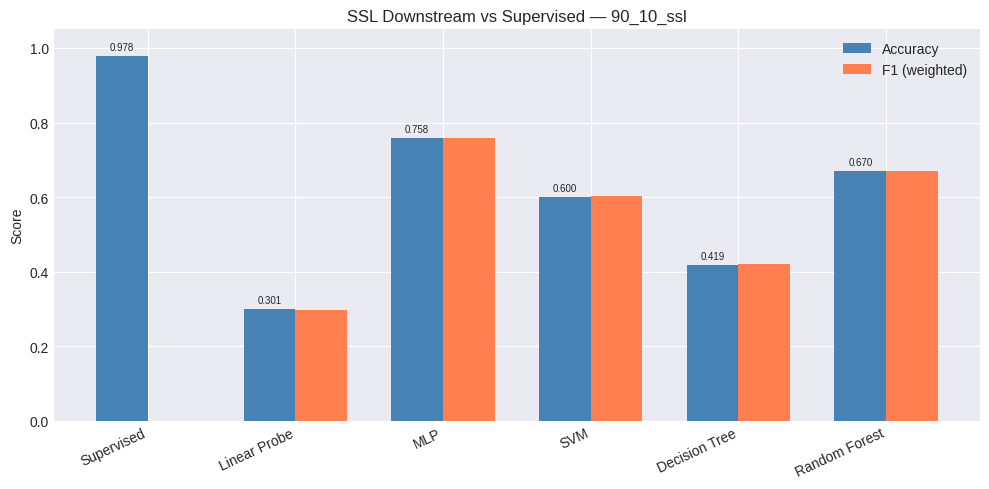

    Comparison chart → downstream_comparison_90_10_ssl.png

  Re-fitting probes for CM/ROC plots (SVM skipped to save time) ...
  Fitting Linear Probe ... 97.3s
  Fitting MLP ... 187.4s
  Fitting Decision Tree ... 27.5s
  Fitting Random Forest ... 134.7s


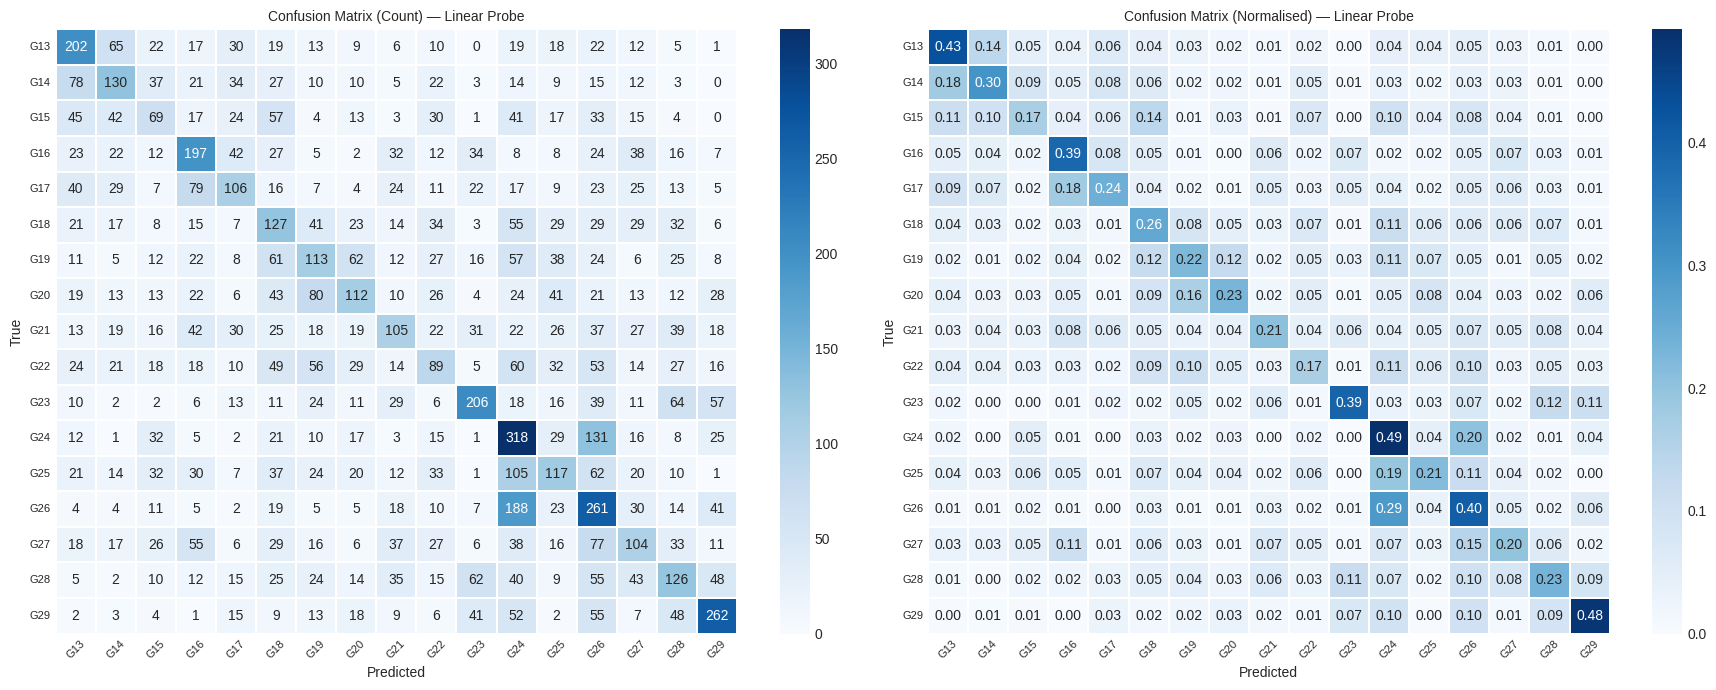

    CM saved -> cm_linear_probe_90_10_ssl.png


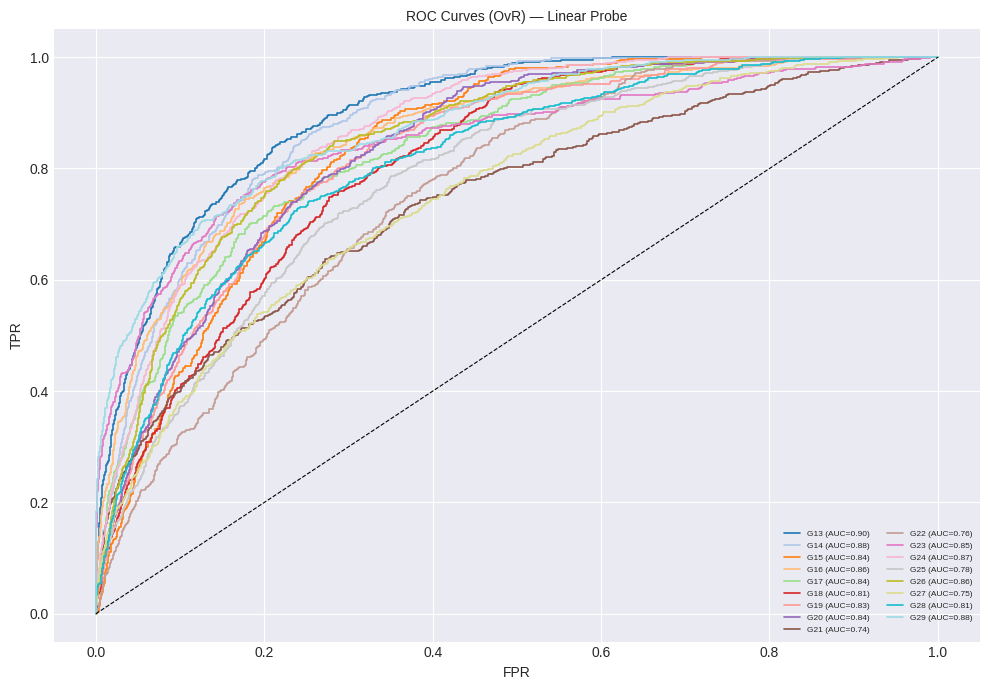

    ROC saved -> roc_linear_probe_90_10_ssl.png


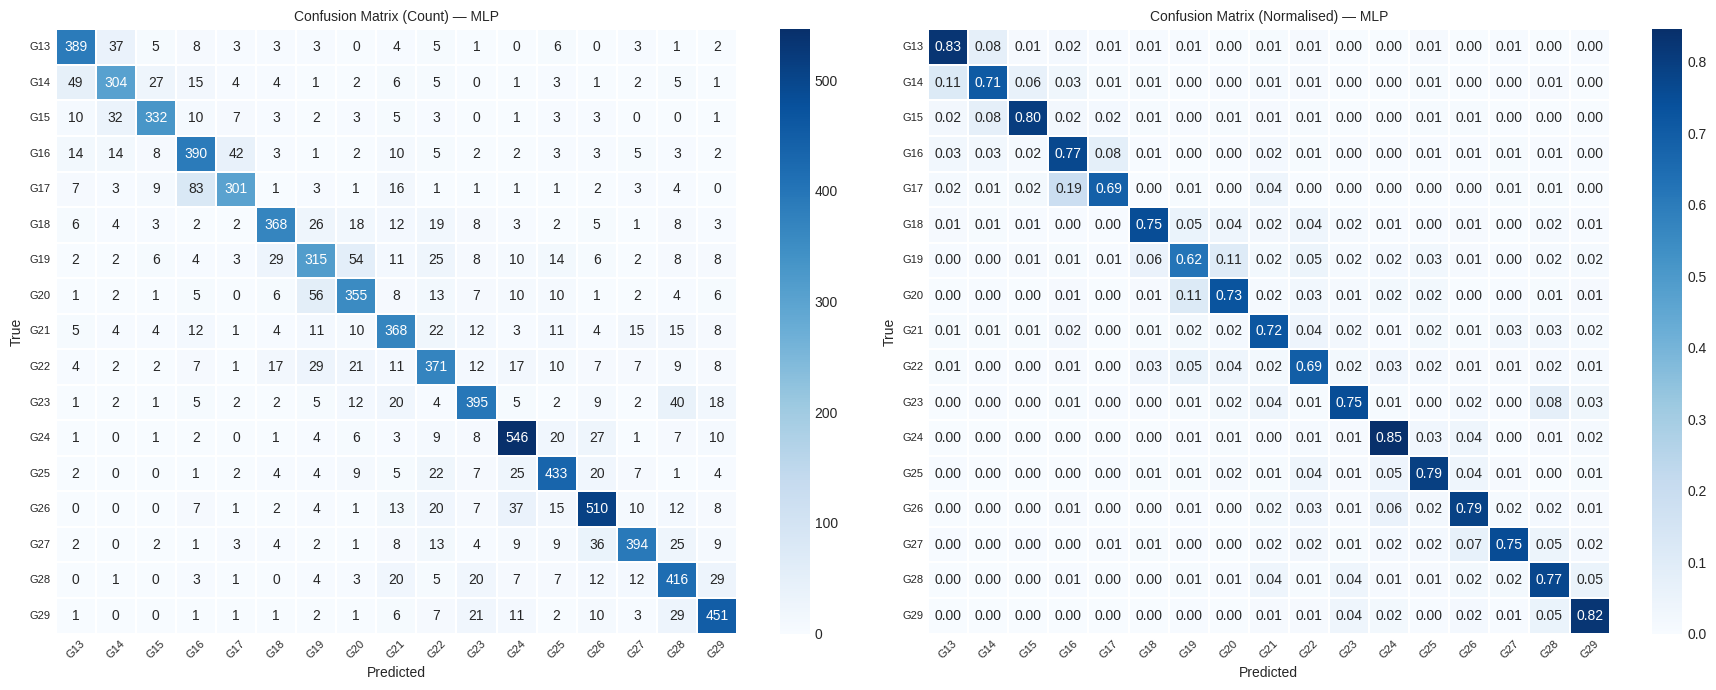

    CM saved -> cm_mlp_90_10_ssl.png


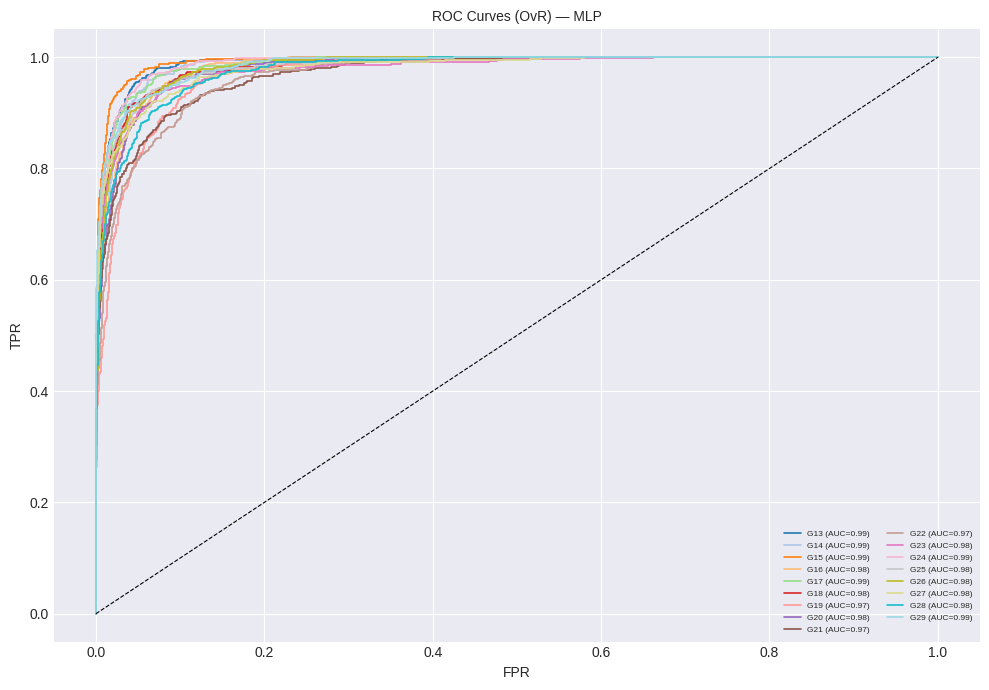

    ROC saved -> roc_mlp_90_10_ssl.png


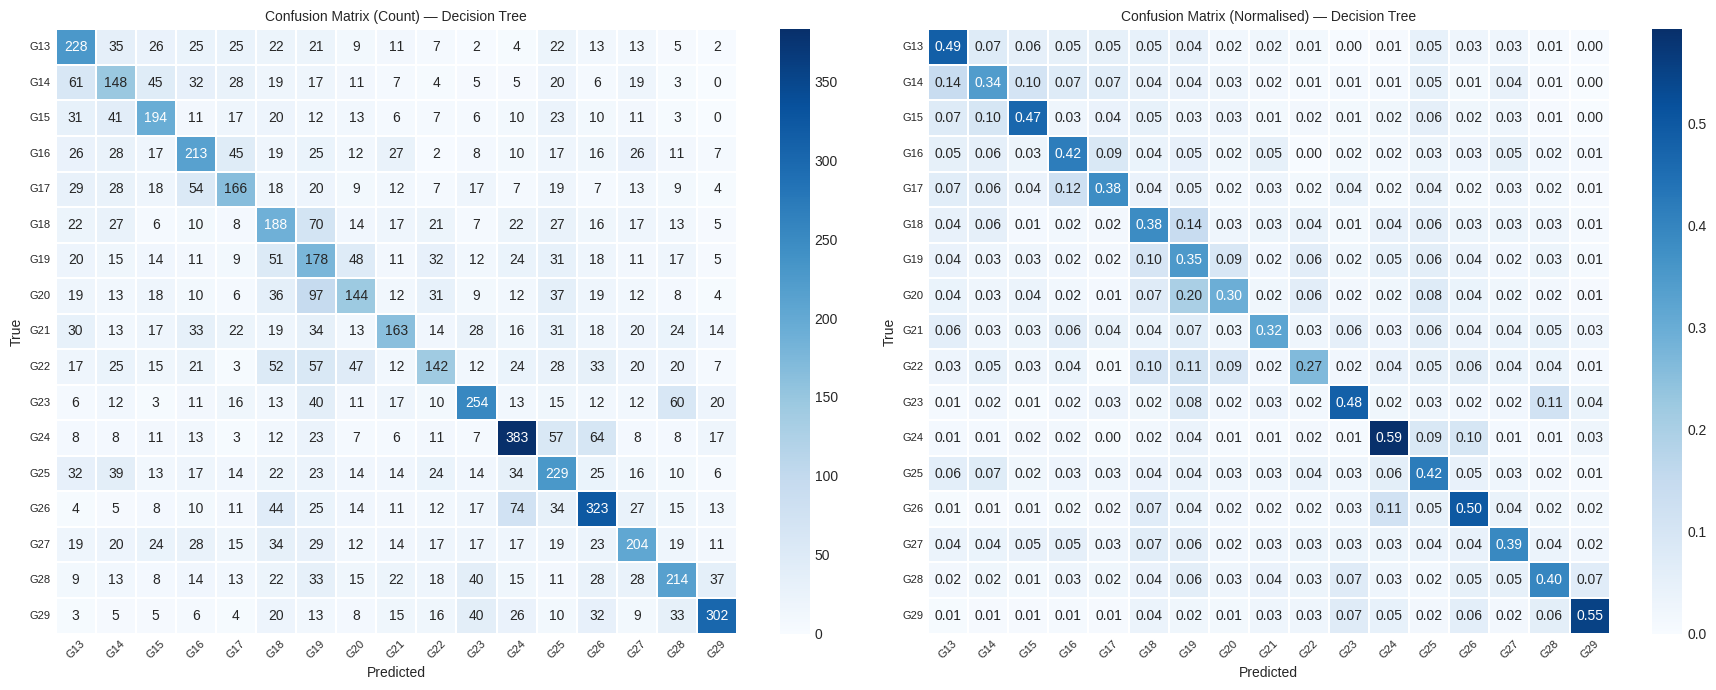

    CM saved -> cm_decision_tree_90_10_ssl.png


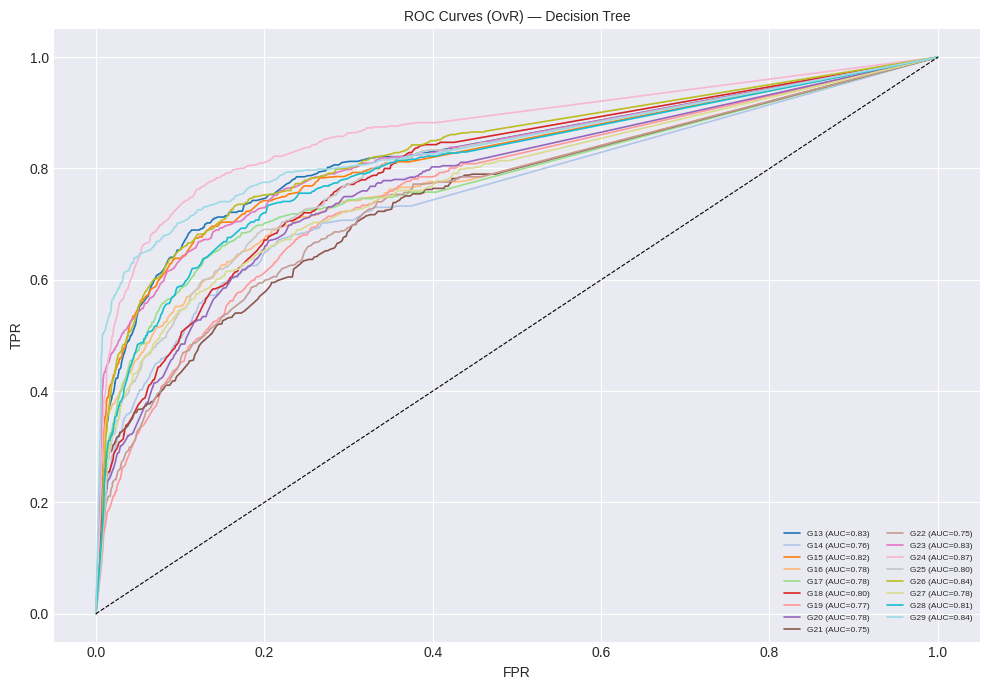

    ROC saved -> roc_decision_tree_90_10_ssl.png


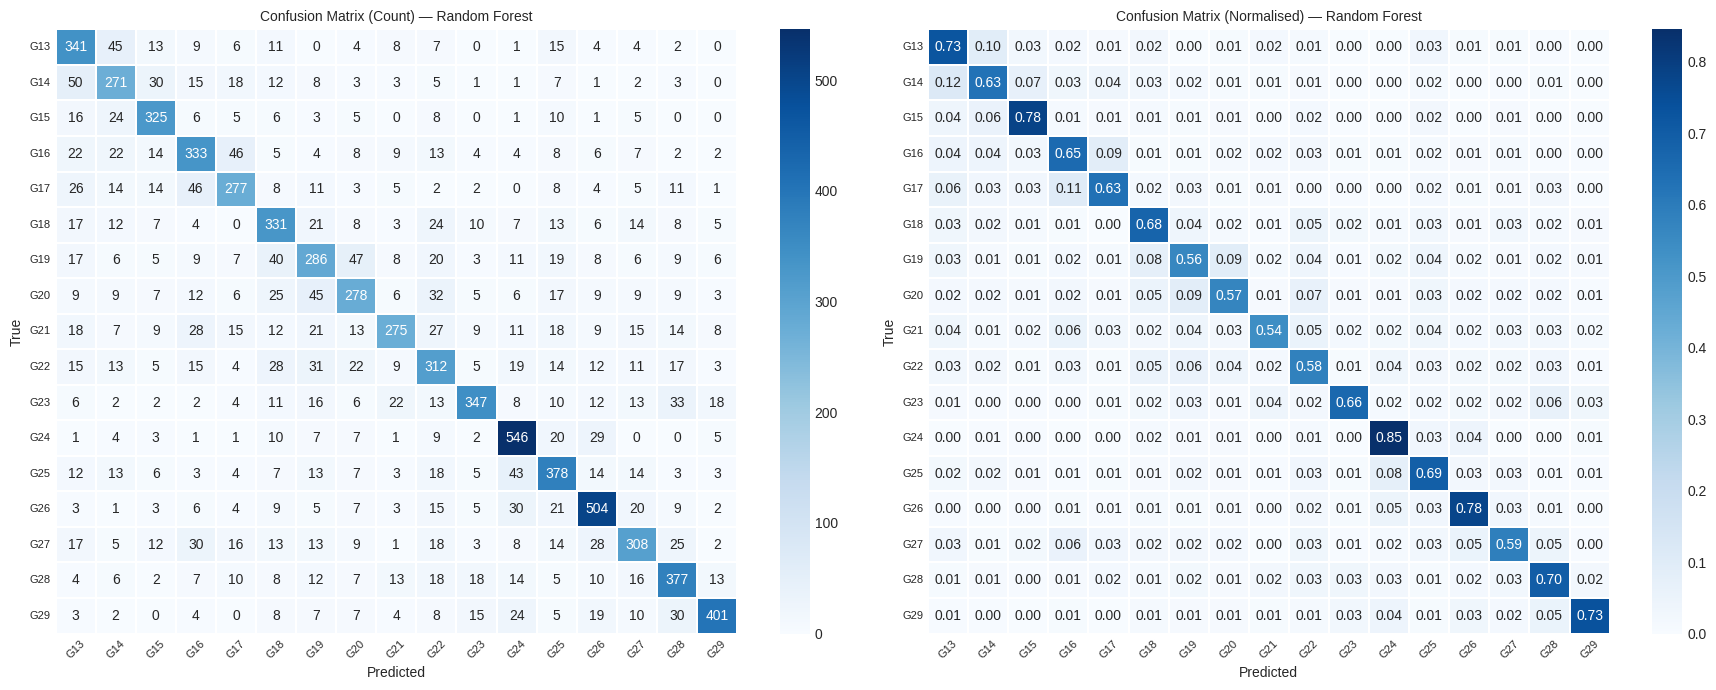

    CM saved -> cm_random_forest_90_10_ssl.png


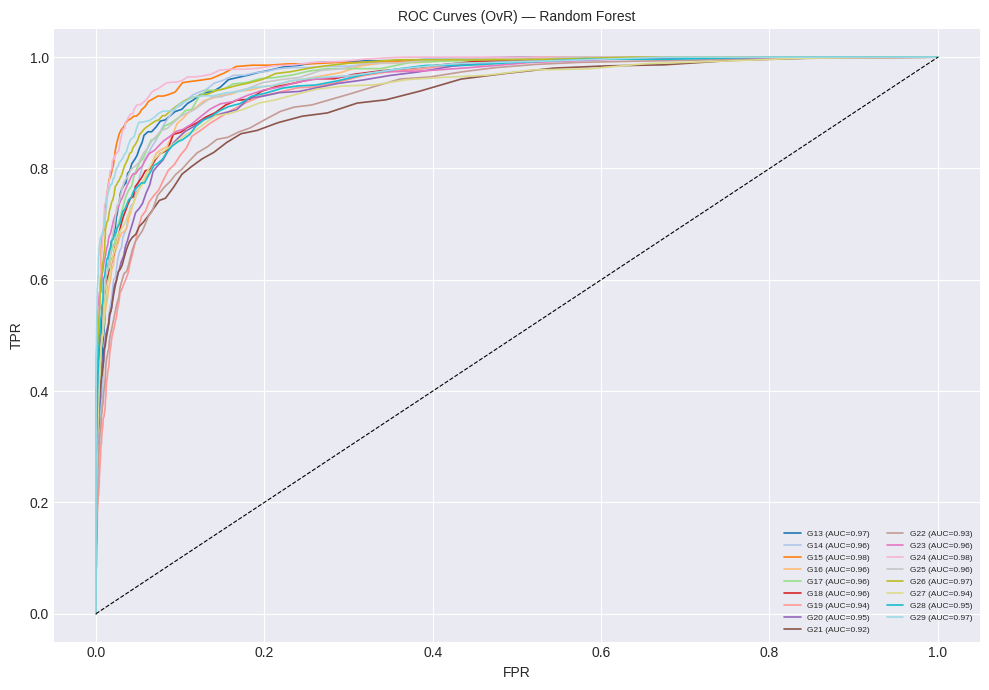

    ROC saved -> roc_random_forest_90_10_ssl.png


In [27]:
# STEP 4 — Probe results (from Part-4) + re-fit for CM/ROC plots (skip SVM)
print("\n" + "="*70)
print("  STEP 4 — Downstream probe results")
print("="*70)

# Results hardcoded from Part-4 run (Linear Probe, MLP, SVM, DT, RF all completed)
probe_results = {
    'Linear Probe':  {'accuracy': 0.3012, 'precision_w': float('nan'),
                      'recall_w': float('nan'), 'f1_w': 0.2961, 'roc_auc_w': float('nan'),
                      'train_time_s': 104.8, 'test_time_s': float('nan'), 'per_class_acc': {}},
    'MLP':           {'accuracy': 0.7583, 'precision_w': float('nan'),
                      'recall_w': float('nan'), 'f1_w': 0.7576, 'roc_auc_w': float('nan'),
                      'train_time_s': 189.5, 'test_time_s': float('nan'), 'per_class_acc': {}},
    'SVM':           {'accuracy': 0.6002, 'precision_w': float('nan'),
                      'recall_w': float('nan'), 'f1_w': 0.6025, 'roc_auc_w': float('nan'),
                      'train_time_s': 2670.8, 'test_time_s': float('nan'), 'per_class_acc': {}},
    'Decision Tree': {'accuracy': 0.4192, 'precision_w': float('nan'),
                      'recall_w': float('nan'), 'f1_w': 0.4202, 'roc_auc_w': float('nan'),
                      'train_time_s': 29.1, 'test_time_s': float('nan'), 'per_class_acc': {}},
    'Random Forest': {'accuracy': 0.6701, 'precision_w': float('nan'),
                      'recall_w': float('nan'), 'f1_w': 0.6698, 'roc_auc_w': float('nan'),
                      'train_time_s': 146.7, 'test_time_s': float('nan'), 'per_class_acc': {}},
}
print("  Probe results from Part-4:")
for name, r in probe_results.items():
    print(f"    {name:<16s}: acc={r['accuracy']:.4f}  f1={r['f1_w']:.4f}  "
          f"({r['train_time_s']:.0f}s train)")

SUPERVISED_METRICS = {
    'split': '90:10', 'accuracy': 0.9781, 'precision_w': 0.9783,
    'recall_w': 0.9781, 'f1_w': 0.9781, 'roc_auc_w': 0.9997,
    'epochs_trained': 173, 'n_params': 900_625,
}

plot_downstream_comparison(probe_results, SUPERVISED_METRICS['accuracy'], TAG)

# Re-fit probes WITHOUT SVM for CM and ROC plots (SVM takes 44 min)
print("\n  Re-fitting probes for CM/ROC plots (SVM skipped to save time) ...")
from sklearn.preprocessing import StandardScaler
scaler_vis = StandardScaler().fit(feat_probe_tr)
Xtr_sc = scaler_vis.transform(feat_probe_tr)
Xte_sc = scaler_vis.transform(feat_te)

fitted_probes = {}
for name, clf in [
    ('Linear Probe', LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs',
                                         multi_class='multinomial', n_jobs=-1,
                                         random_state=Config.SEED)),
    ('MLP',          MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                                   early_stopping=True, validation_fraction=0.1,
                                   random_state=Config.SEED)),
    ('Decision Tree',DecisionTreeClassifier(max_depth=15, random_state=Config.SEED)),
    ('Random Forest',RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                            random_state=Config.SEED)),
]:
    print(f"  Fitting {name} ...", end=" ", flush=True)
    t0 = time.perf_counter()
    clf.fit(Xtr_sc, lbl_probe_tr)
    print(f"{time.perf_counter()-t0:.1f}s")
    fitted_probes[name] = clf

# Confusion matrices and ROC curves for each probe
n_cls = N_CLASSES
colors = plt.cm.tab20(np.linspace(0, 1, n_cls))
for name, clf in fitted_probes.items():
    y_pred = clf.predict(Xte_sc)
    cm  = confusion_matrix(lbl_te, y_pred, labels=list(range(n_cls)))
    cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, mat, lbl in zip(axes, [cm, cmn], ['Count', 'Normalised']):
        sns.heatmap(mat, ax=ax, cmap='Blues',
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    annot=True, fmt='.2f' if lbl == 'Normalised' else 'd',
                    linewidths=0.3)
        ax.set_title(f"Confusion Matrix ({lbl}) — {name}", fontsize=10)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', rotation=0,  labelsize=8)
    plt.tight_layout()
    safe = name.lower().replace(' ', '_')
    path = Config.PLOT_DIR / f'cm_{safe}_{TAG}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f"    CM saved -> {path.name}")

    if hasattr(clf, 'predict_proba'):
        y_proba = clf.predict_proba(Xte_sc)
        fig, ax = plt.subplots(figsize=(10, 7))
        for c in range(n_cls):
            if (lbl_te == c).sum() == 0: continue
            fpr, tpr, _ = roc_curve((lbl_te == c).astype(int), y_proba[:, c])
            try:
                auc_c = roc_auc_score((lbl_te == c).astype(int), y_proba[:, c])
            except Exception:
                auc_c = float('nan')
            ax.plot(fpr, tpr, color=colors[c], lw=1.2,
                    label=f"{CLASS_NAMES[c]} (AUC={auc_c:.2f})")
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f"ROC Curves (OvR) — {name}", fontsize=10)
        ax.legend(fontsize=6, ncol=2, loc='lower right')
        plt.tight_layout()
        path = Config.PLOT_DIR / f'roc_{safe}_{TAG}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show(); plt.close('all')
        print(f"    ROC saved -> {path.name}")



  STEP 5 — Fine-tuning (resume from epoch 10)
  Resuming fine-tune from tinymyo_90_10_ssl_finetune.latest.pt ...
  Resumed from epoch 10  (history: 10 entries)  -> continuing to epoch 100  | wall limit: 28000s
    [ckpt] latest saved at epoch 15 -> tinymyo_90_10_ssl_finetune.latest.pt
    [ckpt] latest saved at epoch 20 -> tinymyo_90_10_ssl_finetune.latest.pt
  Epoch  20  train_loss=0.2025 train_acc=0.9293  val_loss=0.1875 val_acc=0.9348  (108.2 min)
    [ckpt] latest saved at epoch 25 -> tinymyo_90_10_ssl_finetune.latest.pt
    [ckpt] latest saved at epoch 30 -> tinymyo_90_10_ssl_finetune.latest.pt
  Epoch  30  train_loss=0.1560 train_acc=0.9451  val_loss=0.1538 val_acc=0.9502  (216.4 min)
    [ckpt] latest saved at epoch 35 -> tinymyo_90_10_ssl_finetune.latest.pt
    [ckpt] latest saved at epoch 40 -> tinymyo_90_10_ssl_finetune.latest.pt
  Epoch  40  train_loss=0.1172 train_acc=0.9599  val_loss=0.1327 val_acc=0.9575  (324.5 min)
    [ckpt] latest saved at epoch 45 -> tinymyo_90_10_s

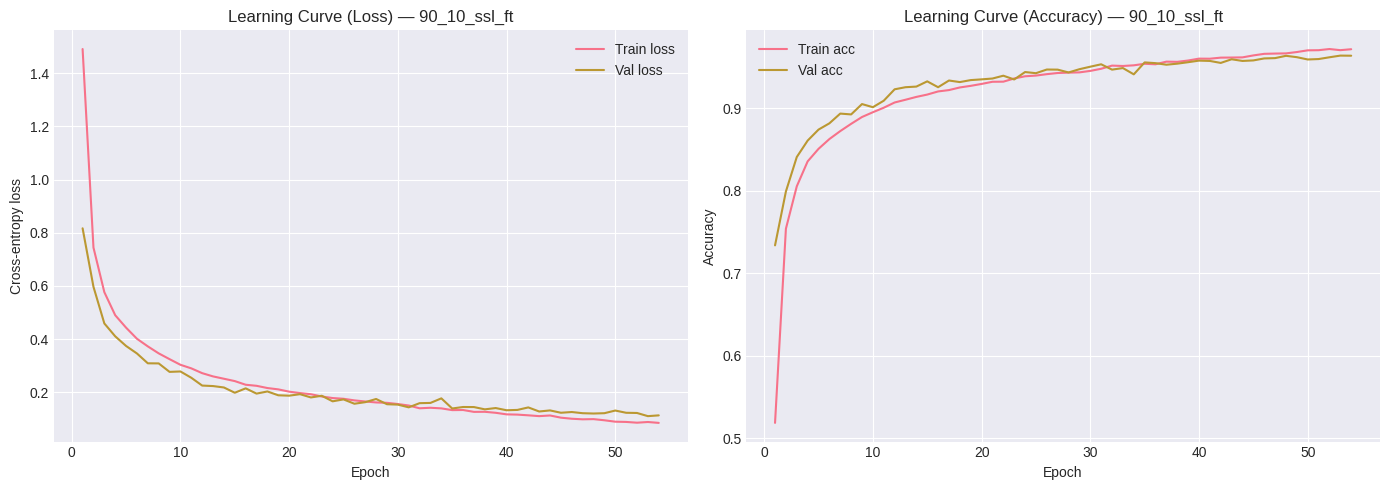

    Curves saved → curves_90_10_ssl_ft.png
  Fine-tune total epochs: 54


In [28]:
# STEP 5 — Resume fine-tuning from epoch 10 with wall-clock guard
print("\n" + "="*70)
print("  STEP 5 — Fine-tuning (resume from epoch 10)")
print("="*70)

ft_trainer = finetune_from_ssl_resume(
    cls_kwargs,
    ssl_path   = ssl_path,
    latest_ft_path = latest_ft,
    train_loader   = tr_loader,
    val_loader     = val_loader,
    save_path      = ft_path,
    n_classes      = N_CLASSES,
    max_wall_s     = Config.FINETUNE_MAX_WALL,
)

plot_learning_curves(ft_trainer.history, TAG + '_ft')
print(f"  Fine-tune total epochs: {len(ft_trainer.history['train_loss'])}")



  STEP 6 — Evaluating fine-tuned model


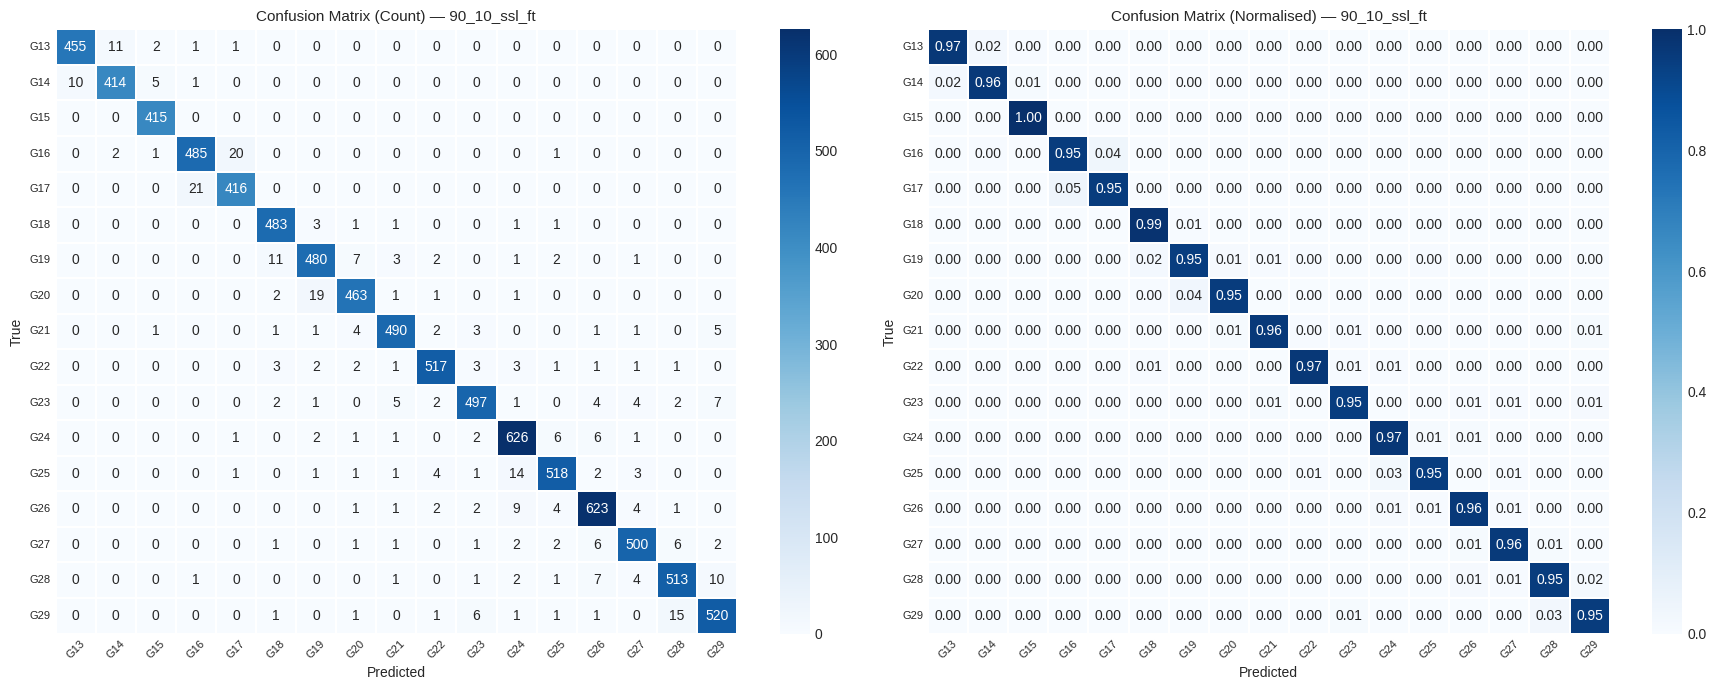

    CM saved → cm_90_10_ssl_ft.png


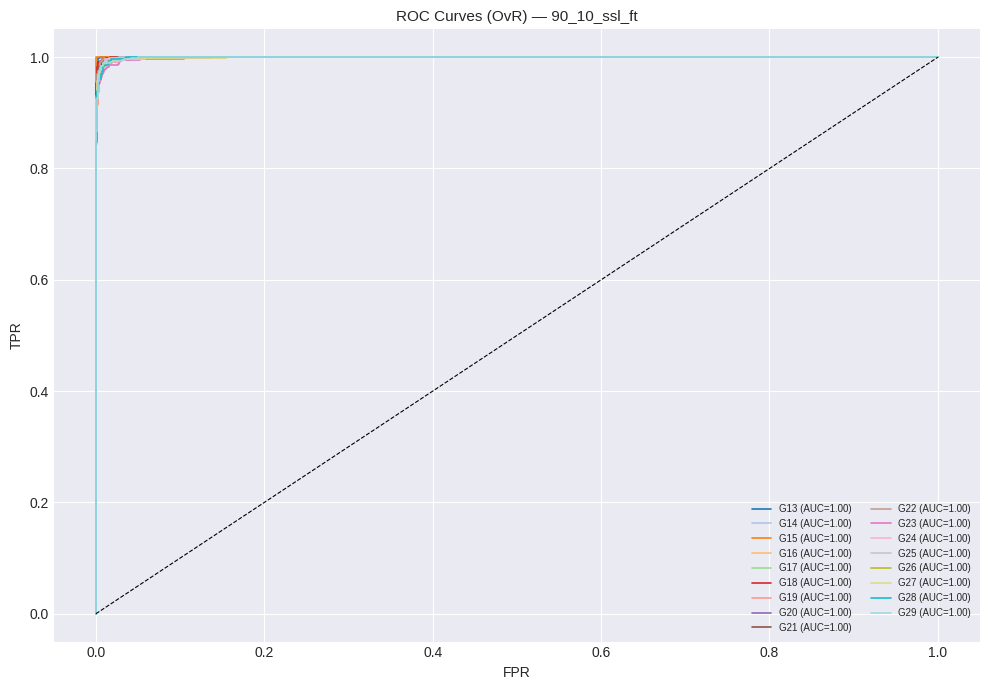

    ROC saved → roc_90_10_ssl_ft.png
  Fine-tune  acc=0.9604  f1=0.9604  ROC-AUC=0.9994
  Linear probe acc=0.3012  delta=+0.6592
  Supervised   acc=0.9781  delta=-0.0177


In [29]:
# STEP 6 — Evaluate fine-tuned model
print("\n" + "="*70)
print("  STEP 6 — Evaluating fine-tuned model")
print("="*70)

if ft_path.exists():
    ft_metrics, ft_true, ft_proba = evaluate_finetuned(
        cls_kwargs, ft_path, tst_loader, N_CLASSES, CLASS_NAMES, TAG + '_ft')
    ft_metrics['train_wall_s']   = ft_trainer.train_wall
    ft_metrics['epochs_trained'] = len(ft_trainer.history['train_loss'])
    print(f"  Fine-tune  acc={ft_metrics['accuracy']:.4f}  "
          f"f1={ft_metrics['f1_w']:.4f}  ROC-AUC={ft_metrics['roc_auc_w']:.4f}")
    lp_acc = probe_results.get('Linear Probe', {}).get('accuracy', 0)
    print(f"  Linear probe acc={lp_acc:.4f}  delta={ft_metrics['accuracy']-lp_acc:+.4f}")
    print(f"  Supervised   acc=0.9781  delta={ft_metrics['accuracy']-0.9781:+.4f}")
else:
    print("  No fine-tune best checkpoint found (training may have hit wall limit)")
    ft_metrics = {}



  STEP 7 — Embedding Analysis (5.3)
    Running t-SNE … done
    Running UMAP … done
    Silhouette score: -0.1302  (n_samples=2000)


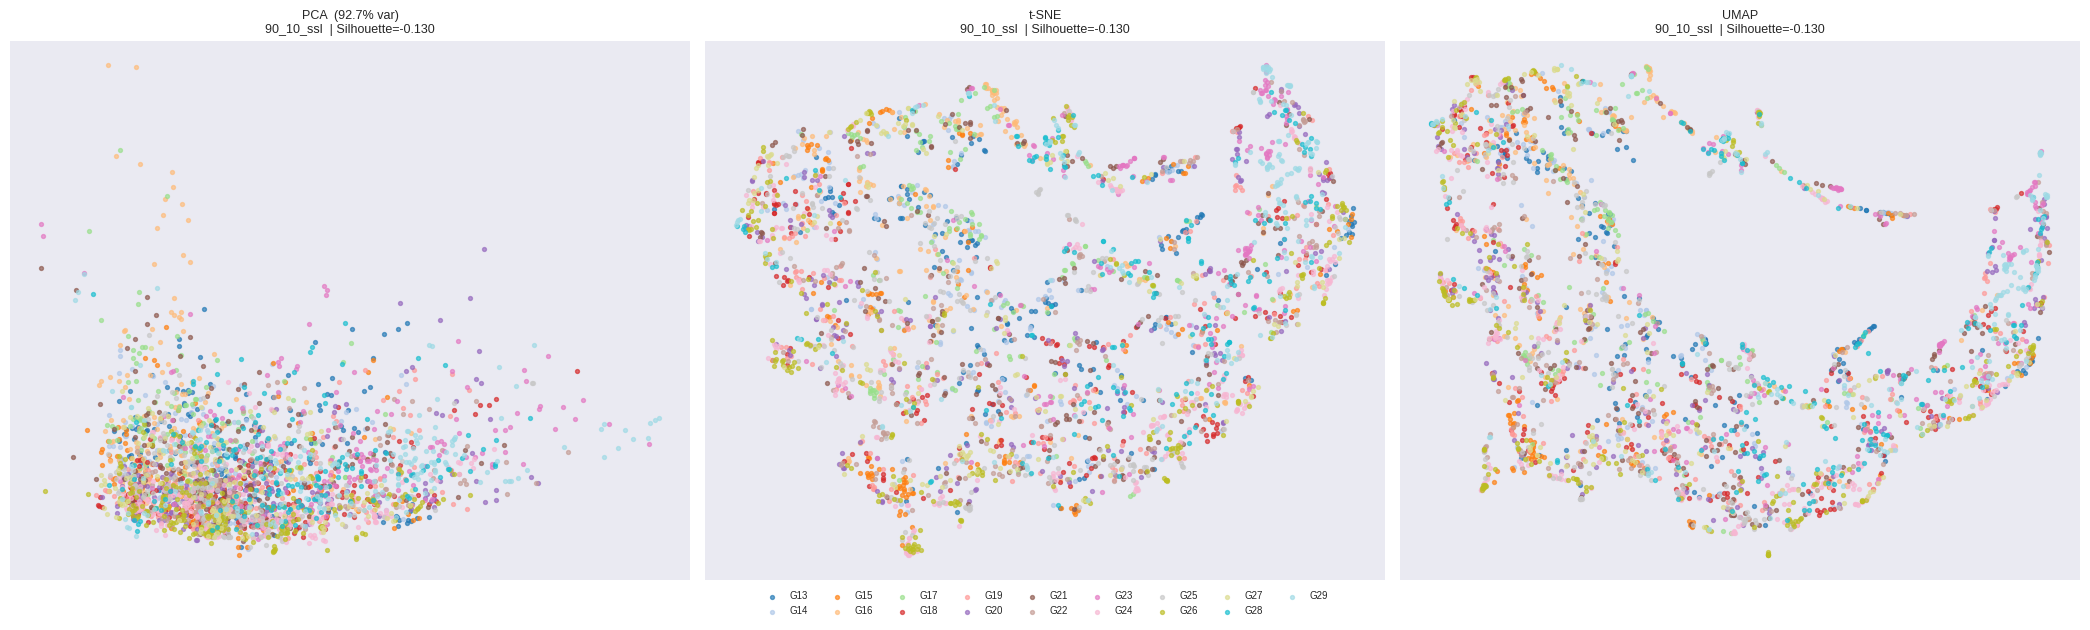

    Embedding plots → embeddings_90_10_ssl.png
  Silhouette score: -0.1302


In [30]:
# STEP 7 — Embedding analysis (t-SNE, UMAP, PCA) on frozen features
print("\n" + "="*70)
print("  STEP 7 — Embedding Analysis (5.3)")
print("="*70)

sil, emb_tsne = plot_embeddings(feat_te, lbl_te, CLASS_NAMES, TAG)
print(f"  Silhouette score: {sil:.4f}")



  STEP 8 — k-NN + Label Efficiency (5.4)
  GFLOPs/window (SSL encoder): -1.0000
  Silhouette score: -0.1302

  k-NN accuracy in embedding space:
    k-NN  k= 1 : acc = 0.6594
    k-NN  k= 5 : acc = 0.6315
    k-NN  k=20 : acc = 0.5980

  Label-efficiency curve (linear probe on frozen features):
       1% labeled  (    788 samples) → acc = 0.1895
       5% labeled  (  3,942 samples) → acc = 0.2215
      10% labeled  (  7,885 samples) → acc = 0.2414
      25% labeled  ( 19,713 samples) → acc = 0.2661
      50% labeled  ( 39,426 samples) → acc = 0.2870


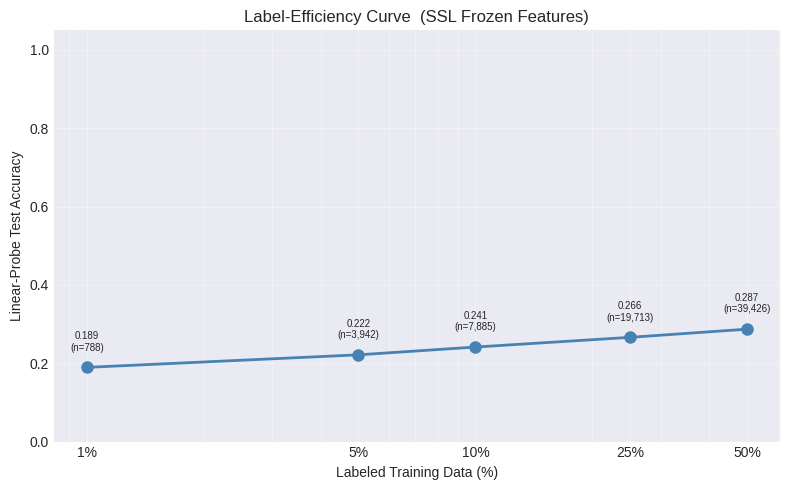

    Label-efficiency plot → label_efficiency.png


In [31]:
# STEP 8 — k-NN accuracy and label-efficiency curve (5.4)
print("\n" + "="*70)
print("  STEP 8 — k-NN + Label Efficiency (5.4)")
print("="*70)

print(f"  GFLOPs/window (SSL encoder): {gflops_ssl:.4f}")
print(f"  Silhouette score: {sil:.4f}")

print("\n  k-NN accuracy in embedding space:")
knn_res = knn_accuracy(feat_probe_tr, lbl_probe_tr, feat_te, lbl_te)

print("\n  Label-efficiency curve (linear probe on frozen features):")
le_res = label_efficiency_curve(feat_probe_tr, lbl_probe_tr, feat_te, lbl_te)


In [32]:
# STEP 9 — Final summary
print("\n" + "="*70)
print("  FINAL SUMMARY — All Methods")
print("="*70)

rows = [{'method': 'Supervised (Part-3)',
         **{k: SUPERVISED_METRICS.get(k, float('nan'))
            for k in ['accuracy', 'precision_w', 'recall_w', 'f1_w', 'roc_auc_w']}}]

for name, res in probe_results.items():
    rows.append({'method': f'SSL frozen -> {name}',
                 **{k: res.get(k, float('nan'))
                    for k in ['accuracy', 'precision_w', 'recall_w', 'f1_w', 'roc_auc_w']}})

if ft_metrics:
    rows.append({'method': 'SSL Fine-tune',
                 **{k: ft_metrics.get(k, float('nan'))
                    for k in ['accuracy', 'precision_w', 'recall_w', 'f1_w', 'roc_auc_w']}})

for k_val, acc in knn_res.items():
    rows.append({'method': f'SSL kNN (k={k_val})',
                 'accuracy': acc, 'precision_w': float('nan'),
                 'recall_w': float('nan'), 'f1_w': float('nan'), 'roc_auc_w': float('nan')})

df = pd.DataFrame(rows)
csv_path = Config.RESULTS_DIR / 'summary_all_methods.csv'
df.to_csv(csv_path, index=False)
print(df[['method', 'accuracy', 'f1_w', 'roc_auc_w']].to_string(index=False))

# Save JSON
ssl_results = {
    'downstream': probe_results, 'finetune': ft_metrics,
    'silhouette': float(sil), 'knn': knn_res,
    'label_efficiency': le_res,
    'ssl_pretraining': {'epochs': 48, 'final_val_mse': 0.282464, 'wall_s': 27940.8},
}
def serialise(obj):
    if isinstance(obj, (np.integer, np.floating)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return str(obj)
jpath = Config.RESULTS_DIR / f'ssl_results_{TAG}.json'
with open(jpath, 'w') as f:
    json.dump(json.loads(json.dumps(ssl_results, default=serialise)), f, indent=2)

print(f"\n  CSV    -> {csv_path}")
print(f"  JSON   -> {jpath}")
print(f"  Plots  -> {Config.PLOT_DIR}")
print(f"  Models -> {Config.CKPT_DIR}")

if 'label_efficiency' in ssl_results:
    print("\n  Label-efficiency (linear probe):")
    for frac, res in sorted(ssl_results['label_efficiency'].items()):
        print(f"    {frac:5.0%} -> acc={res['accuracy']:.4f}  (n={res['n_labeled']:,})")



  FINAL SUMMARY — All Methods
                     method  accuracy     f1_w  roc_auc_w
        Supervised (Part-3)  0.978100 0.978100   0.999700
 SSL frozen -> Linear Probe  0.301200 0.296100        NaN
          SSL frozen -> MLP  0.758300 0.757600        NaN
          SSL frozen -> SVM  0.600200 0.602500        NaN
SSL frozen -> Decision Tree  0.419200 0.420200        NaN
SSL frozen -> Random Forest  0.670100 0.669800        NaN
              SSL Fine-tune  0.960397 0.960378   0.999447
              SSL kNN (k=1)  0.659438      NaN        NaN
              SSL kNN (k=5)  0.631477      NaN        NaN
             SSL kNN (k=20)  0.598037      NaN        NaN

  CSV    -> /kaggle/working/results_exB/summary_all_methods.csv
  JSON   -> /kaggle/working/results_exB/ssl_results_90_10_ssl.json
  Plots  -> /kaggle/working/plots_exB
  Models -> /kaggle/working/ckpts_exB

  Label-efficiency (linear probe):
       1% -> acc=0.1895  (n=788)
       5% -> acc=0.2215  (n=3,942)
      10% -> acc=0.